# Compare all of Parameters:
* norm_random vs. norm_subjectindipendent
* learn-rate: 1e-3 vs. 1e-4 vs. 1e-5 vs. 1e-6
* batch-size: 64 vs. 32 vs. 128
* Dataset-size(train & test): (1000 & 200) vs. (10000 & 2000) 


In [3]:
# 1: Bib

import time

import os
import re
import json
import csv
from pathlib import Path
from scipy import stats
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
from torchvision.models import (
    resnet18,
    ResNet18_Weights
)
from datetime import datetime

from torch.utils.tensorboard import SummaryWriter



I0000 00:00:1790164654.803862 2098016 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790164657.229939 2098016 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:

# 2: Dataset Class: transfer CSV in PyTorch.
class GazeDataset(Dataset):

    def __init__(self, csv_file, transform=None, dataset_size=None, read_all4once=True):

        self.df = pd.read_csv(csv_file)
        self.transform = transform
        self.dataset_size = dataset_size if dataset_size is not None else len(self.df)
        self.read_all4once = read_all4once

        if self.read_all4once:
            img = Image.new("RGB", (500, 300))  # any size
            out = transform(img)
            self.images = torch.zeros([self.dataset_size] + list(out.shape))
            self.targets = torch.zeros(self.dataset_size, 2)

        for idx in tqdm(range(self.dataset_size)):

            row = self.df.iloc[idx]

            image = Image.open(
                row["image_name"]
            ).convert("RGB")

            self.targets[idx] = torch.tensor(
                [row["x"], row["y"]],
                dtype=torch.float32
            )

            if self.transform:
                self.images[idx] = self.transform(image)
            else:
                self.images[idx] = image

    def __len__(self):

        return self.dataset_size

    def __getitem__(self, idx):

        return self.images[idx], self.targets[idx]

In [5]:

# 5: func-Diagonal-Error:
def diagonal_errors(model, loader, device):
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    
    mae = mean_absolute_error(targets, predictions)
    
    rmse = np.sqrt(mean_squared_error(targets, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [6]:
def diagonal_errors2(model, loader, device):
    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    
    mae = mean_absolute_error(targets, predictions)
    
    rmse = np.sqrt(mean_squared_error(targets, predictions))

    diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    return mae, rmse, diagonal_error_pct

In [7]:
def evaluate_model(model, loader, device):

    model.eval()

    targets_list = []
    preds_list = []

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            preds = model(images)
            targets_list.append(targets.cpu().numpy())
            preds_list.append(preds.cpu().numpy())

    targets = np.concatenate(targets_list, axis=0)
    predictions = np.concatenate(preds_list, axis=0)
    
    # mae = mean_absolute_error(targets, predictions)
    
    # rmse = np.sqrt(mean_squared_error(targets, predictions))

    # diagonal_error_pct = np.round(100 * (rmse / np.sqrt(2)), 5)

    errors = np.sqrt(
        np.sum(
            (predictions-targets)**2,
            axis=1
        )
    )

    # print(f"MAE : {mae:.4f} \t RMSE: {rmse:.4f} ")
    # print(f"RMSE: {rmse:.4f}")
    # print(f"Diagonal-Error %: {diagonal_error_pct:.4f} %")

    # return mae, rmse, diagonal_error_pct, targets, predictions, errors
    return targets, predictions, errors

In [8]:
class GaussianActivation(nn.Module):

    def __init__(self, sigma=1.0):
        super().__init__()
        self.sigma = sigma

    def forward(self, x):
        return torch.exp(
            -(x ** 2) / (2 * self.sigma ** 2)
        )

In [9]:
def sensitive_loss(preds, targets):

    x_total = 0.0

    for i in range(len(targets)):

        x = criterion_base(preds[i], targets[i])

        distance_from_center = (
            torch.abs(targets[i][0] - 0.5) +
            torch.abs(targets[i][1] - 0.5)
        )

        weight = 1.0 + distance_from_center

        x_total += x * weight

    return x_total / len(targets)

In [10]:
def confidence_interval(data, confidence=0.95):

    data = np.asarray(data)

    n = len(data)

    mean = np.mean(data)
    std = np.std(data, ddof=1)

    standard_error = std / np.sqrt(n)

    t_value = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    margin = t_value * standard_error

    lower = mean - margin
    upper = mean + margin

    return mean, lower, upper

# Hypoparameter:

* dataset_size (train-size & test-size)
* batch_size 
* learn-rate
* norm_random vs. norm_subject


In [51]:
# Hypoparameter:

name_dataset_type = ['norm_labels.csv', 'labels.csv']
dataset_size_type = [[10000, 2000], [1000, 200]]
dataset_type = ["norm_subject", "norm_random"]
batch_size_type = [32, 64, 128]
lr_type = [1e-3, 1e-4, 1e-5, 1e-6] 
epochs_num = [1, 2, 10, 25, 500]



optimizer_name = "AdamW"

# ##########################################################################
# 1.type Dataset: 'norm_labels.csv' or 'labels.csv'
dataset_name = name_dataset_type[0]                       # norm_labels.csv
# dataset_name = name_dataset_type[1]                       # labels.csv
print(f"\n dataset_name: \t {dataset_name}")


# 2.dataset_sizt: (10000 & 2000) or (1000, 200)
# def_dataset_size = dataset_size_type[0]                   # [10000, 2000]
def_dataset_size = dataset_size_type[1]                   # [1000, 200]
print(f"\n def_dataset_size: train: {def_dataset_size[0]}, \t test: {def_dataset_size[1]}")


# 3.batch_size: '32', '64' or '128'
batch_Size = batch_size_type[0]                           # 32
# batch_Size = batch_size_type[1]                           # 64
# batch_Size = batch_size_type[2]                           # 128
print(f"\n batch_Size: \t {batch_Size}")


# 4.type of dataset-split: "norm_subject_independed" or "norm_random"
# def_dataset = dataset_type[0]                             # norm_subject
def_dataset = dataset_type[1]                             # norm_random
print(f"\n def_dataset: \t {def_dataset}")


# 5.learning_rate: '1e-3', '1e-4', '1e-5' or '1e-6'
lr_type = [1e-3, 1e-4, 1e-5, 1e-6] 
# learning_rate = lr_type[0]                                # 1e-3
learning_rate = lr_type[1]                                # 1e-4
# learning_rate = lr_type[2]                                # 1e-5
# learning_rate = lr_type[3]                                # 1e-6
print(f"\n learning_rate: \t {learning_rate}")


# 6.number of epochs: 1, 2, 10, 25 or 500
epochs = epochs_num[-1]                                   # 500
print(f"\n epochs: \t {epochs}")




weight_Decay = 1e-5

active_func = None

patience = 3               # after 3 Epochen without Optimierung has to stop training
print(f"\n patience: \t {patience}")



 dataset_name: 	 norm_labels.csv

 def_dataset_size: train: 1000, 	 test: 200

 batch_Size: 	 32

 def_dataset: 	 norm_random

 learning_rate: 	 0.0001

 epochs: 	 500

 patience: 	 3


In [ ]:
# name_dataset_type = ['norm_labels.csv', 'labels.csv']
# dataset_size_type = [[10000, 2000], [1000, 200]]
# dataset_type = ["norm_subject", "norm_random"]
# batch_size_type = [32, 64, 128]
# lr_type = [1e-3, 1e-4, 1e-5, 1e-6] 
# epochs_num = [1, 2, 10, 25, 500]

# optimizer_name = "AdamW"

# # ##########################################################################
# # 1.type Dataset: 'norm_labels.csv' or 'labels.csv'
# dataset_name = name_dataset_type[0]                       # norm_labels.csv
# # dataset_name = name_dataset_type[1]                       # labels.csv

# # 2.dataset_sizt: (10000 & 2000) or (1000, 200)
# # def_dataset_size = dataset_size_type[0]                   # [10000, 2000]
# def_dataset_size = dataset_size_type[1]                   # [1000, 200]

# # 3.batch_size: '32', '64' or '128'
# # batch_Size = batch_size_type[0]                           # 32
# # batch_Size = batch_size_type[1]                           # 64
# batch_Size = batch_size_type[2]                           # 128

# # 4.type of dataset-split: "norm_subject_independed" or "norm_random"
# def_dataset = dataset_type[0]                             # norm_subject
# # def_dataset = dataset_type[1]                             # norm_random

# # 5.learning_rate: '1e-3', '1e-4', '1e-5' or '1e-6'
# lr_type = [1e-3, 1e-4, 1e-5, 1e-6] 
# learning_rate = lr_type[0]                                # 1e-3
# # learning_rate = lr_type[1]                                # 1e-4
# # learning_rate = lr_type[2]                                # 1e-5
# # learning_rate = lr_type[3]                                # 1e-6

# epochs = epochs_num[-1]                                   # 500

# weight_Decay = 1e-5
# active_func = None
# patience = 3               # after 3 Epochen without Optimierung has to stop training

In [52]:
# 6: CSV laden
root_folder = "./dataset"
csv_path = Path(f"{root_folder}/{dataset_name}")
# print(f"\n csv_path: {csv_path}")

df = pd.read_csv(csv_path)
df.head()
# check:
# print(df.shape)

,image_name,x,y,subject_ID,screen_w,screen_h
0,dataset/images/00002/00002/frames/00000.jpg,0.500000,0.500000,2,320,568
1,dataset/images/00002/00002/frames/00001.jpg,0.500000,0.500000,2,320,568
2,dataset/images/00002/00002/frames/00002.jpg,0.500000,0.500000,2,320,568
3,dataset/images/00002/00002/frames/00003.jpg,0.500000,0.500000,2,320,568
4,dataset/images/00002/00002/frames/00004.jpg,0.873929,0.114375,2,320,568


In [53]:
# 8: DataLoader
# Transformationen:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    transforms.RandomGrayscale(p=0.05),

    transforms.GaussianBlur(
        kernel_size=3,
        sigma=(0.1,1.5)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Dataset:


if def_dataset == 'norm_subject':

    train_dataset = GazeDataset(
        "./splits/norm_subject_train.csv",
        transform, dataset_size=def_dataset_size[0],
    )
    
    test_dataset = GazeDataset(
        "./splits/norm_subject_test.csv",
        transform, dataset_size=def_dataset_size[1],
    )



elif def_dataset == 'norm_random':

    train_dataset = GazeDataset(
        "./splits/norm_random_train.csv",
        transform, dataset_size=def_dataset_size[0],
    )
    
    test_dataset = GazeDataset(
        "./splits/norm_random_test.csv",
        transform, dataset_size=def_dataset_size[1],
    )

else:

    raise ValueError(
                "The input as dataset_type is Wrong!"
            )


# Loader:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_Size,
    shuffle=True,
    num_workers=8,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_Size,
    shuffle=False,
    num_workers=8,
    persistent_workers=True
)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 104.75it/s]


In [54]:
# 9: ResNet18 (Pretrainiertes Modell):
# Load:
def reset_model(act=None):
    model = resnet18(
        weights=ResNet18_Weights.DEFAULT
    )

    model_name = model.__class__.__name__
    
    # ---------------------------------------
    # Activation function for the last layer
    # ---------------------------------------
    if act == "Sigmoid":
        last_layer = nn.Sigmoid()

    elif act == "Gaussian":
        last_layer = GaussianActivation(sigma=1.0)

    elif act == "ReLU":
        last_layer = nn.ReLU()

    elif act == "None":
        last_layer = nn.Identity()

    else:
        raise ValueError(
            f"Unknown activation function: {act}"
        )

    # ---------------------------------------
    # Replace original ResNet FC
    # ---------------------------------------
    model.fc = nn.Sequential(
        nn.Linear(
            model.fc.in_features,
            512
        ),
        nn.ReLU(),

        nn.Linear(
            512,
            256
        ),
        nn.ReLU(),

        nn.Dropout(0.2),

        nn.Linear(
            256,
            128
        ),
        nn.ReLU(),

        nn.Linear(
            128,
            2
        ),

        # Last activation
        last_layer
    )

    return model, model_name

In [55]:
# 10: GPU or CPU
# check:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

In [56]:

# ============================================================
# Fixed configuration: NORMALIZED DATASET
# ============================================================

# acts = ['Sigmoid', 'Gaussian', 'ReLU', 'None']
act = "Sigmoid"

trainable_layers = "FC only"


print("\n" + "=" * 70)
print("NORMALIZED DATASET EXPERIMENT: ")


print(f"\tDataset_type:         {dataset_name}")
print(f"\tDataset split:        {def_dataset}")
print(f"\tTrain size:           {def_dataset_size[0]}")
print(f"\tTest size:            {def_dataset_size[1]}")
print(f"\tBatch size:           {batch_Size}")
print(f"\tLearning rate:        {learning_rate}")
print(f"\tActivation:           {act}")
print(f"\tTrainable layers:     {trainable_layers}")
print(f"\tMax_Epochs:           {epochs}")
print(f"\tPatience:             {patience}")
print("=" * 70)




if globals().get("bas_const_err") is None:
    bas_const_err = 27.245

if globals().get("bas_rand_err") is None:
    bas_rand_err = 38.961



# --------------------------------------------------------
# Start total training timer
# --------------------------------------------------------

train_start = time.perf_counter()



epochs = epochs



model_output = './models/best_models'
model_dir= Path(model_output)

if not os.path.exists(model_dir):
    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )


diagrams_output = './results/best_diagrams'
diagrams_dir= Path(diagrams_output)

if not os.path.exists(diagrams_dir):
    diagrams_dir.mkdir(
        parents=True,
        exist_ok=True
    )



# ============================================================
# Store train and test error curves
# ============================================================

# train_errors = []
# test_errors = []

best_error = float("inf")

patience_counter = 0                        # Number Epochen without Optimierung
improvements = 0                            # Number Epochen with Optimierung
best_epoch = 0

diag_train_errors = []
diag_test_errors  = []

act_time_epochs = {}



criterion = nn.L1Loss()

criterion_base = nn.L1Loss()

# --------------------------------------------------------
# Reset model
# --------------------------------------------------------

model, model_name = reset_model(act=act)

model.to(device)

# --------------------------------------------------------
# Freeze all parameters
# --------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False


# --------------------------------------------------------
# Unfreeze ONLY FC
# --------------------------------------------------------

for param in model.layer4.parameters():
    param.requires_grad=False


for param in model.fc.parameters():
    param.requires_grad = True



# --------------------------------------------------------
# Optimizer
# --------------------------------------------------------

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_Decay
)





print('\n ',"=#=" * 25)
print(f"\t\t last Active Function: {act}")
print(' ',"=#=" * 25)


# ============================================================
# Initial evaluation before training
# ============================================================
print("\n\t Initial evaluation: \n")

model.eval()

print("train_error:")
train_mae, train_rmse, train_diag_pct = diagonal_errors(
    model,
    train_loader,
    device
)

train_diag_pct = np.round(float(train_diag_pct), 4)
diag_train_errors.append(train_diag_pct)




print("\ntest_error:")
test_mae, test_rmse, test_diag_pct = diagonal_errors(
    model,
    test_loader,
    device
)

test_diag_pct = np.round(float(test_diag_pct), 4)
diag_test_errors.append(test_diag_pct)



print(
    f"Epoch 0 | "
    f"Train error: {train_diag_pct:.4f}% | "
    f"Test error: {test_diag_pct:.4f}%"
)



# Initial best test error
if best_error is None or test_diag_pct < best_error:  
    best_error = test_diag_pct
    best_epoch = 0


# save the better Modell
torch.save(
    model.state_dict(),
    f"./models/best_models/"
    f"best_{model_name}_{act}_{def_dataset}.path"
)

# ============================================================
# Training
# ============================================================

print("\n\n\t Training: \n")

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()

    running_loss = 0.0


    loop = tqdm(
        train_loader,
        desc=f"Normalized | Epoch {epoch + 1}"
    )
    

    for images, targets in loop:
        
        images = images.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        
        preds = model(images)

        ################################
        # Loss 1:
        ################################
        
        loss = criterion(
            preds,
            targets
        )


        
        ################################
        # Loss 2: 
        ################################
        
        # loss = sensitive_loss(
        #     preds,
        #     targets
        # )
        
        ################################

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        loop.set_postfix(
            loss=loss.item()
        )

    

    # ========================================================
    # Evaluation after epoch
    # ========================================================

    model.eval()


    # --------------------------------------------------------
    # Train error
    # --------------------------------------------------------
    print("\n Train:")
    train_mae, train_rmse, train_diag_pct = diagonal_errors(
        model,
        train_loader,
        device
    )

    train_diag_pct = np.round(float(train_diag_pct), 4)
    diag_train_errors.append(train_diag_pct)


    # --------------------------------------------------------
    # Test error
    # --------------------------------------------------------
    print("\n Test:")
    test_mae, test_rmse, test_diag_pct = diagonal_errors(
        model,
        test_loader,
        device
    )

    test_diag_pct = np.round(float(test_diag_pct), 4)
    diag_test_errors.append(test_diag_pct)


    # --------------------------------------------------
    # Early Stopping
    # --------------------------------------------------

    if test_diag_pct < best_error:

        best_error = test_diag_pct

        best_epoch = epoch + 1

        patience_counter = 0
        improvements += 1

        print(
            f"\nTest-Diagonal-Error: "
            f"{test_diag_pct:.4f}% | "
            f"Improvement: {improvements}"
        )

        # save the better Modell
        torch.save(
            model.state_dict(),
            f"./models/best_models/"
            f"best_{model_name}_{act}_{def_dataset}.path"
        )
    

    else:

        # without imporovement
        patience_counter += 1

        print(
            f"\nPatience: "
            f"{patience_counter}/{patience}"
        )


        if patience_counter >= patience:

            print(
                f"\nEarly Stopping after "
                f"{epoch + 1} epochs."
            )
            print(
                f"Imporovments totally: {improvements}"
            )

            break
    

    # ========================================================
    # Epoch information
    # ========================================================

    epoch_end = time.perf_counter()

    epoch_time = epoch_end - epoch_start


    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] "
        f"Epoch {epoch + 1}: | " 
        f"{epoch_time:.2f} s | "
        f"Loss: {running_loss / len(train_loader):.4f} | "
        f"Train-Error: {train_diag_pct:.4f}% | "
        f"Test-Error: {test_diag_pct:.4f}%"
    )

    torch.save(
            model.state_dict(),
            f"./models/best_models/"
            f"last_{model_name}_{act}_{def_dataset}.path"
        )



# ============================================================
# Total running time
# ============================================================

train_end = time.perf_counter()

elapsed_running_time = train_end - train_start

elapsed_minutes = elapsed_running_time / 60

print(f"\ntotll running-tiems (s): {elapsed_running_time:.2f} s")
print(f"totll running-tiems (min): {elapsed_minutes:.2f} min\n")

# ============================================================
# Number of completed epochs
# ============================================================

epochs_completed = len(diag_test_errors)


# # ============================================================
# # Store normalized-dataset results
# # ============================================================

norm_results = {
    "dataset": "normalized",
    "dataset_split": def_dataset,
    "train_size": def_dataset_size[0],
    "test_size": def_dataset_size[1],
    "batch_size": batch_Size,
    "learning_rate": learning_rate,
    "activation": act,
    "trainable_layers": trainable_layers,
    "patience": patience,
    "train_errors": diag_train_errors,
    "test_errors": diag_test_errors,
    "best_test_error": best_error,
    "running_time_minutes": elapsed_minutes,
    "epochs": epochs_completed,
    "best_epoch": best_epoch,
    "improvements": improvements
}


# ========================================================
# Print result for this learning rate
# ========================================================

print("\n" + "=" * 70)
print("NORMALIZED DATASET RESULTS")
print("=" * 70)

print(
    f"Best Test Error:   {norm_results['best_test_error']:.4f}%"
)
print(
    f"Running Time:      {norm_results['running_time_minutes']:.2f} min"
)
print(
    f"Epochs:            {norm_results['epochs']}"
)
print(
    f"Best Epoch:        {norm_results['best_epoch']}"
)
print(
    f"Improvements:      {norm_results['improvements']}"
)
print("=" * 70)





act_time_epochs[act] = {
    "time_minutes": elapsed_minutes,
    "epochs": epoch + 1,
    "improvements": improvements,
    "best_test_error": best_error
}




NORMALIZED DATASET EXPERIMENT: 
	Dataset_type:         norm_labels.csv
	Dataset split:        norm_random
	Train size:           1000
	Test size:            200
	Batch size:           32
	Learning rate:        0.0001
	Activation:           Sigmoid
	Trainable layers:     FC only
	Max_Epochs:           500
	Patience:             3

  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=
		 last Active Function: Sigmoid
  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=

	 Initial evaluation: 

train_error:
MAE : 0.2465 	 RMSE: 0.2915 
Diagonal-Error %: 20.6127 %

test_error:
MAE : 0.2167 	 RMSE: 0.2670 
Diagonal-Error %: 18.8772 %
Epoch 0 | Train error: 20.6127% | Test error: 18.8772%


	 Training: 



Normalized | Epoch 1: 100%|███████████████████████████████████████████████████████████| 32/32 [00:47<00:00,  1.48s/it, loss=0.24]



 Train:
MAE : 0.2436 	 RMSE: 0.2899 
Diagonal-Error %: 20.4980 %

 Test:
MAE : 0.2204 	 RMSE: 0.2668 
Diagonal-Error %: 18.8678 %

Test-Diagonal-Error: 18.8678% | Improvement: 1

[16:55:30] Epoch 1: | 94.95 s | Loss: 0.2455 | Train-Error: 20.4980% | Test-Error: 18.8678%


Normalized | Epoch 2: 100%|██████████████████████████████████████████████████████████| 32/32 [00:48<00:00,  1.50s/it, loss=0.323]



 Train:
MAE : 0.2399 	 RMSE: 0.2864 
Diagonal-Error %: 20.2542 %

 Test:
MAE : 0.2208 	 RMSE: 0.2664 
Diagonal-Error %: 18.8366 %

Test-Diagonal-Error: 18.8366% | Improvement: 2

[16:57:06] Epoch 2: | 95.66 s | Loss: 0.2449 | Train-Error: 20.2542% | Test-Error: 18.8366%


...


 Train:
MAE : 0.2366 	 RMSE: 0.2846 
Diagonal-Error %: 20.1217 %

 Test:
MAE : 0.2240 	 RMSE: 0.2704 
Diagonal-Error %: 19.1169 %

Patience: 1/3

[16:58:38] Epoch 3: | 90.16 s | Loss: 0.2376 | Train-Error: 20.1217% | Test-Error: 19.1170%


Normalized | Epoch 4: 100%|██████████████████████████████████████████████████████████| 32/32 [00:42<00:00,  1.33s/it, loss=0.258]



 Train:
MAE : 0.2341 	 RMSE: 0.2837 
Diagonal-Error %: 20.0602 %

 Test:
MAE : 0.2248 	 RMSE: 0.2703 
Diagonal-Error %: 19.1124 %

Patience: 2/3

[17:00:08] Epoch 4: | 90.62 s | Loss: 0.2379 | Train-Error: 20.0602% | Test-Error: 19.1124%


Normalized | Epoch 5: 100%|██████████████████████████████████████████████████████████| 32/32 [00:43<00:00,  1.37s/it, loss=0.327]



 Train:
MAE : 0.2327 	 RMSE: 0.2828 
Diagonal-Error %: 19.9986 %

 Test:
MAE : 0.2267 	 RMSE: 0.2745 
Diagonal-Error %: 19.4081 %

Patience: 3/3

Early Stopping after 5 epochs.
Imporovments totally: 2

totll running-tiems (s): 516.66 s
totll running-tiems (min): 8.61 min


NORMALIZED DATASET RESULTS
Best Test Error:   18.8366%
Running Time:      8.61 min
Epochs:            6
Best Epoch:        2
Improvements:      2


In [57]:
for act, values in act_time_epochs.items():
    print(
        f" last_layer: {act} |"
        f" epochs: {values['epochs']} Epochen |"
        f" running_time: {values['time_minutes']:.2f} min |"
        f" improvements: {values['improvements']} Epochen |"
        f" best_test_error: {values['best_test_error']:.4f} % |"
    )

 last_layer: Sigmoid | epochs: 5 Epochen | running_time: 8.61 min | improvements: 2 Epochen | best_test_error: 18.8366 % |


In [ ]:

print(f"\n\n Diagonal-Train-Error: {np.float64(diag_train_error)}\n")
print(f" Diagonal-Test-Error: {np.float64(diag_test_error)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(diag_train_error)} \t Diagonal-Train-Error-Min: {np.min(diag_train_error)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(diag_test_error)}\t Diagonal-Test-Error-Min: {np.min(diag_test_error)}\t max_needed_epochs: {e+2}\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")


if globals().get("bas_const_err") is None:
    bas_const_err = 27.245

if globals().get("bas_rand_err") is None:
    bas_rand_err = 38.961


# Curven:

# Minimum Test Error bestimmen
min_test_error = min(diag_test_error)
min_test_epoch = diag_test_error.index(min_test_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = diag_train_error[min_test_epoch - 1]
test_at_min = diag_test_error[min_test_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

# Die Farbe
train_color = "tab:blue"
test_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# Epochs beginnen bei 1
epochs = range(1, len(diag_test_error) + 1)
# epochs = range(0, len(diag_test_error) + 1)

plt.figure(figsize=(10, 7))

# Train Error
plt.plot(epochs, diag_train_error, label="Train", linewidth=2, color=train_color)


# Test Error
plt.plot(epochs, diag_test_error, label="Test", linewidth=2, color=test_color)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.3f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=test_color,
    fontsize=8,
)


plt.title("Train- vs. Test-Error:")
plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

plt.grid(True, alpha=0.3, linewidth=0.6)
plt.legend()



# ===================================================
# =============== all 4 Diagrams ====================
# ===================================================


plt.figure(figsize=(10, 7))


# Train Error
plt.plot(
    epochs,
    diag_train_error,
    label="Train",
    linewidth=2,
    color=train_color
)


# Test Error
plt.plot(
    epochs,
    diag_test_error,
    label="Test",
    linewidth=2,
    color=test_color
)


# Constant Baseline
plt.plot(
    epochs,
    [bas_const_err] * len(epochs),
    label="Constant Error",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random Baseline
plt.plot(
    epochs,
    [bas_rand_err] * len(epochs),
    label="Random Error",
    linestyle="-.",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)



print(f"\nMinimum Test Error:")
print(f"Epoch:           {min_test_epoch}")
print(f"Test Error:      {test_at_min:.4f}%")
print(f"Train Error:     {train_at_min:.4f}%")
print(f"Constant Error:  {bas_const_err:.4f}%")
print(f"Random Error:    {bas_rand_err:.4f}%\n")


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_test_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)


# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(5, 5),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.3f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(5, 7),
    textcoords="offset points",
    color=test_color,
    fontsize=8
)

plt.annotate(
    f"'Constant': {const_at_min:.3f}%",
    xy=(min_test_epoch, const_at_min),
    xytext=(5, 10),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.3f}%",
    xy=(min_test_epoch, rand_at_min),
    xytext=(5, -15),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)

# Titel
plt.title(
    f"{def_dataset} "
    f"(train:{def_dataset_size[0]}, test:{def_dataset_size[1]})\n"
    f"lr = {learning_rate} | "
    f"{elapsed_running_time / 60:.2f} Minuten | "
    f"extra_act_fun: {active_func} | "
    f"epochs_improvements_totally: {e + 2}"
)
# plt.title(f"{def_dataset}((train:{def_dataset_size[0]}, test:{def_dataset_size[1]})) \n" 
#           f" lr = {learning_rate} | {elapsed_running_time/60:.2f} Minuten | extra_act_fun: {active_func} | epochs_imporovments_totally: {e+2}"
# )

plt.xlabel("Epoche")
plt.ylabel("Diagnostic Error (%)")

plt.xticks(epochs)

# plt.xticks(range(1, len(epochs) + 1, 1))
# plt.yticks(range(0, 51, 5))

plt.grid(True, alpha=0.4)
plt.legend()

# Ordner erstellen (falls er noch nicht existiert)
os.makedirs("./results", exist_ok=True)

# Diagramm speichern
plt.savefig(
    f"results/diag_error_{def_dataset}_{learning_rate}_{def_dataset_size[0]}_{def_dataset_size[1]}_a.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [132]:

# ============================================================
# Fixed configuration: NORMALIZED DATASET
# ============================================================

act = "Sigmoid"

patience = 7

trainable_layers = "FC only"


print("\n" + "=" * 70)
# print("NORMALIZED DATASET EXPERIMENT")
print("Raw DATASET EXPERIMENT")
print("=" * 70)

print(f"Dataset:              {dataset_name}")
print(f"Dataset split:        {def_dataset}")
print(f"Train size:           {def_dataset_size[0]}")
print(f"Test size:            {def_dataset_size[1]}")
print(f"Batch size:           {batch_Size}")
print(f"Learning rate:        {learning_rate}")
print(f"Activation:           {act}")
print(f"Trainable layers:     {trainable_layers}")
print(f"Max_Epochs:           {epochs}")
print(f"Patience:             {patience}")
print("=" * 70)



# ============================================================
# Store train and test error curves
# ============================================================

train_errors = []
test_errors = []

best_error = float("inf")

patience_counter = 0
improvements = 0
best_epoch = 0




criterion = nn.L1Loss()



# --------------------------------------------------------
# Start total training timer
# --------------------------------------------------------

train_start = time.perf_counter()


# --------------------------------------------------------
# Reset model
# --------------------------------------------------------

model, model_name = reset_model(act=act)

model.to(device)

# --------------------------------------------------------
# Freeze all parameters
# --------------------------------------------------------

for param in model.parameters():
    param.requires_grad = False


# --------------------------------------------------------
# Unfreeze ONLY FC
# --------------------------------------------------------

for param in model.fc.parameters():
    param.requires_grad = True


# --------------------------------------------------------
# Optimizer
# --------------------------------------------------------

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
    weight_decay=weight_Decay
)



# ============================================================
# Initial evaluation before training
# ============================================================

print("\nInitial evaluation:")

model.eval()


train_mae, train_rmse, train_diag_pct = diagonal_errors(
    model,
    train_loader,
    device
)

test_mae, test_rmse, test_diag_pct = diagonal_errors(
    model,
    test_loader,
    device
)


train_diag_pct = float(train_diag_pct)
test_diag_pct = float(test_diag_pct)


print(
    f"Epoch 0 | "
    f"Train error: {train_diag_pct:.4f}% | "
    f"Test error: {test_diag_pct:.4f}%"
)



# Initial best test error
if test_diag_pct < best_error:
    best_error = test_diag_pct
    best_epoch = 0


# ============================================================
# Training
# ============================================================

for epoch in range(epochs):

    epoch_start = time.perf_counter()

    model.train()

    running_loss = 0.0


    loop = tqdm(
        train_loader,
        desc=f"Normalized | Epoch {epoch + 1}"
    )

    # loop = tqdm(
    #     train_loader,
    #     desc=f"Row | Epoch {epoch + 1}"
    # )

    for images, targets in loop:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        preds = model(images)


        # ----------------------------------------------------
        # L1 Loss
        # ----------------------------------------------------

        loss = criterion(
            preds,
            targets
        )


        loss.backward()

        optimizer.step()


        running_loss += loss.item()


        loop.set_postfix(
            loss=loss.item()
        )


    # ========================================================
    # Evaluation after epoch
    # ========================================================

    model.eval()


    # --------------------------------------------------------
    # Train error
    # --------------------------------------------------------

    train_mae, train_rmse, train_diag_pct = diagonal_errors(
        model,
        train_loader,
        device
    )


    # --------------------------------------------------------
    # Test error
    # --------------------------------------------------------

    test_mae, test_rmse, test_diag_pct = diagonal_errors(
        model,
        test_loader,
        device
    )


    train_diag_pct = float(train_diag_pct)
    test_diag_pct = float(test_diag_pct)


    # --------------------------------------------------------
    # Store errors
    # --------------------------------------------------------

    train_errors.append(train_diag_pct)
    test_errors.append(test_diag_pct)


    # ========================================================
    # Early stopping
    # ========================================================

    if test_diag_pct < best_error:

        best_error = test_diag_pct

        best_epoch = epoch + 1

        patience_counter = 0
        improvements += 1

        print(
            f"\nTest-Diagonal-Error: "
            f"{test_diag_pct:.4f}% | "
            f"Improvement: {improvements}"
        )

    else:

        patience_counter += 1

        print(
            f"\nPatience: "
            f"{patience_counter}/{patience}"
        )


        if patience_counter >= patience:

            print(
                f"\nEarly Stopping after "
                f"{epoch + 1} epochs."
            )

            break


    # ========================================================
    # Epoch information
    # ========================================================

    epoch_end = time.perf_counter()

    epoch_time = epoch_end - epoch_start


    print(
        f"\n[{datetime.now().strftime('%H:%M:%S')}] "
        f"Epoch {epoch + 1}: | " 
        f"{epoch_time:.2f} s | "
        f"Loss: {running_loss / len(train_loader):.4f} | "
        f"Train: {train_diag_pct:.4f}% | "
        f"Test: {test_diag_pct:.4f}%"
    )


# ============================================================
# Total running time
# ============================================================

train_end = time.perf_counter()

elapsed_running_time = train_end - train_start

elapsed_minutes = elapsed_running_time / 60


# ============================================================
# Number of completed epochs
# ============================================================

epochs_completed = len(test_errors)


# # ============================================================
# # Store normalized-dataset results
# # ============================================================

# norm_results = {

#     "dataset": "normalized",

#     "dataset_split": def_dataset,

#     "train_size": def_dataset_size[0],

#     "test_size": def_dataset_size[1],

#     "batch_size": batch_Size,

#     "learning_rate": learning_rate,

#     "activation": act,

#     "trainable_layers": trainable_layers,

#     "patience": patience,

#     "train_errors": train_errors,

#     "test_errors": test_errors,

#     "best_test_error": best_error,

#     "running_time_minutes": elapsed_minutes,

#     "epochs": epochs_completed,

#     "best_epoch": best_epoch,

#     "improvements": improvements
# }


# ============================================================
# Store raw-dataset results
# ============================================================

raw_results = {

    "dataset": "raw",

    "dataset_split": def_dataset,

    "train_size": def_dataset_size[0],

    "test_size": def_dataset_size[1],

    "batch_size": batch_Size,

    "learning_rate": learning_rate,

    "activation": act,

    "trainable_layers": trainable_layers,

    "patience": patience,

    "train_errors": train_errors,

    "test_errors": test_errors,

    "best_test_error": best_error,

    "running_time_minutes": elapsed_minutes,

    "epochs": epochs_completed,

    "best_epoch": best_epoch,

    "improvements": improvements
}

# ========================================================
# Print result for this learning rate
# ========================================================

# print("\n" + "=" * 70)
# print("NORMALIZED DATASET RESULTS")
# print("=" * 70)

# print(
#     f"Best Test Error:   {norm_results['best_test_error']:.4f}%"
# )

# print(
#     f"Running Time:      {norm_results['running_time_minutes']:.2f} min"
# )

# print(
#     f"Epochs:            {norm_results['epochs']}"
# )

# print(
#     f"Best Epoch:        {norm_results['best_epoch']}"
# )

# print(
#     f"Improvements:      {norm_results['improvements']}"
# )

# print("=" * 70)

# ========================================================
# Print result for this learning rate
# ========================================================

print("\n" + "=" * 70)
# print("NORMALIZED DATASET RESULTS")
print("NORMALIZED DATASET RESULTS")
print("=" * 70)

print(
    f"Best Test Error:   {raw_results['best_test_error']:.4f}%"
)

print(
    f"Running Time:      {raw_results['running_time_minutes']:.2f} min"
)

print(
    f"Epochs:            {raw_results['epochs']}"
)

print(
    f"Best Epoch:        {raw_results['best_epoch']}"
)

print(
    f"Improvements:      {raw_results['improvements']}"
)

print("=" * 70)



Raw DATASET EXPERIMENT
Dataset:              labels.csv
Dataset split:        norm_subject
Train size:           1000
Test size:            200
Batch size:           32
Learning rate:        0.0001
Activation:           Sigmoid
Trainable layers:     FC only
Max_Epochs:           500
Patience:             7

Initial evaluation:
MAE : 0.2326 	 RMSE: 0.2798 
Diagonal-Error %: 19.7830 %
MAE : 0.2378 	 RMSE: 0.2840 
Diagonal-Error %: 20.0811 %
Epoch 0 | Train error: 19.7830% | Test error: 20.0811%


Row | Epoch 1: 100%|█████████████████████████████████████████████████████████████████| 32/32 [00:37<00:00,  1.17s/it, loss=0.196]


MAE : 0.2293 	 RMSE: 0.2775 
Diagonal-Error %: 19.6255 %
MAE : 0.2391 	 RMSE: 0.2856 
Diagonal-Error %: 20.1958 %

Patience: 1/7

[20:32:13] Epoch 1: | 79.67 s | Loss: 0.2301 | Train: 19.6255% | Test: 20.1958%


Row | Epoch 2: 100%|█████████████████████████████████████████████████████████████████| 32/32 [00:39<00:00,  1.25s/it, loss=0.229]


MAE : 0.2265 	 RMSE: 0.2740 
Diagonal-Error %: 19.3771 %
MAE : 0.2356 	 RMSE: 0.2832 
Diagonal-Error %: 20.0231 %

Test-Diagonal-Error: 20.0231% | Improvement: 1

[20:33:38] Epoch 2: | 84.74 s | Loss: 0.2288 | Train: 19.3771% | Test: 20.0231%


...

MAE : 0.2140 	 RMSE: 0.2645 
Diagonal-Error %: 18.7033 %
MAE : 0.2513 	 RMSE: 0.2985 
Diagonal-Error %: 21.1091 %

Patience: 5/7

[20:40:39] Epoch 7: | 85.46 s | Loss: 0.2201 | Train: 18.7033% | Test: 21.1091%


Row | Epoch 8: 100%|█████████████████████████████████████████████████████████████████| 32/32 [00:40<00:00,  1.27s/it, loss=0.249]


MAE : 0.2103 	 RMSE: 0.2617 
Diagonal-Error %: 18.5022 %
MAE : 0.2517 	 RMSE: 0.2988 
Diagonal-Error %: 21.1265 %

Patience: 6/7

[20:42:07] Epoch 8: | 87.88 s | Loss: 0.2164 | Train: 18.5022% | Test: 21.1265%


Row | Epoch 9: 100%|█████████████████████████████████████████████████████████████████| 32/32 [00:40<00:00,  1.25s/it, loss=0.216]


MAE : 0.2112 	 RMSE: 0.2631 
Diagonal-Error %: 18.6010 %
MAE : 0.2444 	 RMSE: 0.2895 
Diagonal-Error %: 20.4717 %

Patience: 7/7

Early Stopping after 9 epochs.

NORMALIZED DATASET RESULTS
Best Test Error:   20.0231%
Running Time:      13.42 min
Epochs:            9
Best Epoch:        2
Improvements:      1


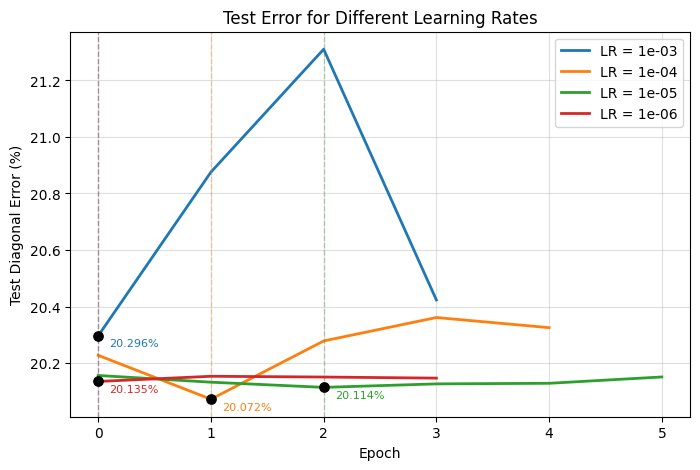

In [97]:
# ============================================================
# Plot: Test Error for all Learning Rates
# ============================================================

if globals().get("bas_const_err") is None:
    bas_const_err = 30.99

if globals().get("bas_rand_err") is None:
    bas_rand_err = 42.70


# ============================================================
# Colors
# ============================================================

lr_colors = {
    1e-3: "tab:blue",
    1e-4: "tab:orange",
    1e-5: "tab:green",
    1e-6: "tab:red"
}

const_color = "tab:purple"
rand_color = "tab:brown"
point_color = "black"


# ============================================================
# Figure
# ============================================================

plt.figure(figsize=(8, 5))


# ============================================================
# Plot every learning-rate curve
# ============================================================

for learning_rate, values in lr_results.items():

    test_errors = values["test_errors"]

    # Epochs start at 0 because test_errors contains
    # the initial evaluation before training
    epochs_axis = range(len(test_errors))

    best_test_error = values["best_test_error"]

    # Epoch of minimum test error
    min_test_epoch = int(np.argmin(test_errors))

    color = lr_colors.get(
        learning_rate,
        None
    )


    # --------------------------------------------------------
    # Test Error Curve
    # --------------------------------------------------------

    plt.plot(
        epochs_axis,
        test_errors,
        label=f"LR = {learning_rate:.0e}",
        linewidth=2,
        color=color
    )


    # --------------------------------------------------------
    # Point at minimum
    # --------------------------------------------------------

    plt.scatter(
        min_test_epoch,
        best_test_error,
        s=45,
        zorder=5,
        color=point_color
    )


    # --------------------------------------------------------
    # Vertical line through minimum
    # --------------------------------------------------------

    plt.axvline(
        x=min_test_epoch,
        linestyle="--",
        linewidth=1.0,
        alpha=0.35,
        color=color
    )


    # --------------------------------------------------------
    # Annotation
    # --------------------------------------------------------

    plt.annotate(
        f"{best_test_error:.3f}%",
        xy=(
            min_test_epoch,
            best_test_error
        ),
        xytext=(8, -8),
        textcoords="offset points",
        color=color,
        fontsize=8
    )


# ============================================================
# Baselines
# ============================================================

# Get maximum number of epochs
# max_epochs = max(
#     len(values["test_errors"])
#     for values in lr_results.values()
# )

# epochs_baseline = range(max_epochs)


# Constant baseline
# plt.plot(
#     epochs_baseline,
#     [bas_const_err] * max_epochs,
#     label="Constant Error",
#     linestyle="--",
#     linewidth=1.2,
#     alpha=0.6,
#     color=const_color
# )


# Random baseline
# plt.plot(
#     epochs_baseline,
#     [bas_rand_err] * max_epochs,
#     label="Random Error",
#     linestyle="-.",
#     linewidth=1.2,
#     alpha=0.6,
#     color=rand_color
# )



# ============================================================
# Labels and title
# ============================================================

# plt.title(
#     f"{def_dataset} "
#     f"(train:{def_dataset_size[0]}, test:{def_dataset_size[1]})\n"
#     f"Batch size = {batch_Size} | "
#     f"Activation = {act} | "
#     f"Trainable = FC only"
# )

plt.title("Test Error for Different Learning Rates")


plt.xlabel("Epoch")

plt.ylabel("Test Diagonal Error (%)")


# ============================================================
# X-axis
# ============================================================

plt.xticks(
    range(max_epochs)
)


# ============================================================
# Y-axis
# ============================================================

# plt.yticks(
#     range(19, 40)
# )

# ============================================================
# Grid and legend
# ============================================================

plt.grid(
    True,
    alpha=0.4
)

plt.legend()


# ============================================================
# Save figure
# ============================================================

# os.makedirs(
#     "./results",
#     exist_ok=True
# )


# plt.savefig(
#     f"results/"
#     f"test_error_learning_rates_"
#     f"{def_dataset}_"
#     f"{def_dataset_size[0]}_"
#     f"{def_dataset_size[1]}_"
#     f"batch{batch_Size}_"
#     f"{act}.png",
#     dpi=300,
#     bbox_inches="tight"
# )


plt.show()

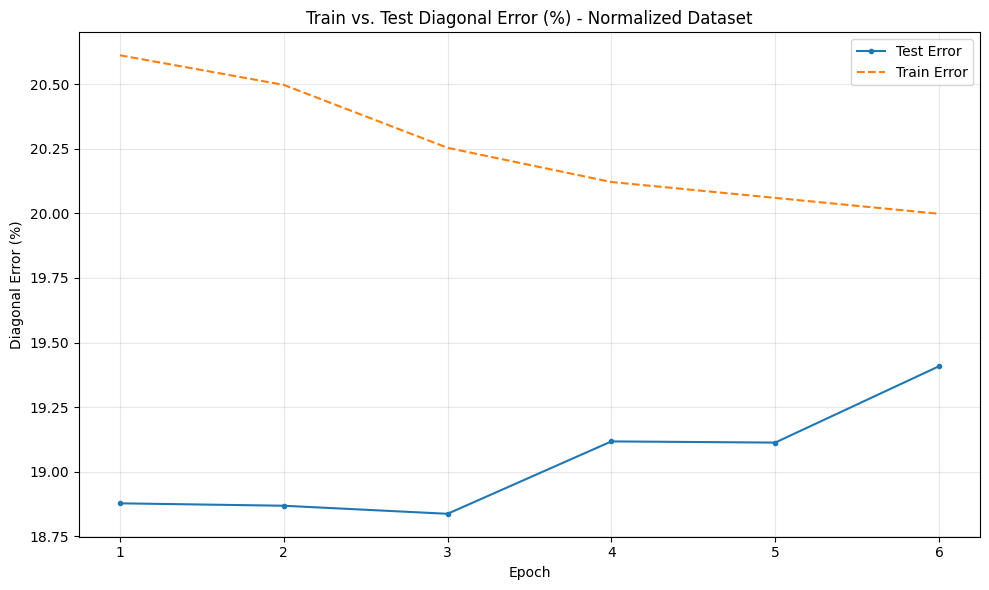

In [58]:
if globals().get("bas_const_err") is None:
    bas_const_err = 30.99

if globals().get("bas_rand_err") is None:
    bas_rand_err = 42.70



# ============================================================
# Plot Test- vs. Train-Diagonal-Errors curves
# ============================================================

plt.figure(figsize=(10, 6))

test_errors = norm_results["test_errors"]
train_errors = norm_results["train_errors"]

# Epochs start at 1 because Epoch 0 was not stored in the lists
epochs_axis = range(1, len(test_errors) + 1)

plt.plot(
    epochs_axis,
    test_errors,
    linestyle="-",
    marker="o",
    markersize=3,
    label="Test Error"
)

plt.plot(
    epochs_axis,
    train_errors,
    linestyle="--",
    marker="",
    markersize=3,
    label="Train Error"
)

#############################################################
"""
# Vertikale Linie durch alle vier Kurven
plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    # label=f"Min Test Error (Epoch {min_test_epoch})"
)

# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)

# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.3f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(8, 10),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.3f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(8, -10),
    textcoords="offset points",
    color=test_color,
    fontsize=8,
)
"""
#############################################################

plt.xlabel("Epoch")
plt.ylabel("Diagonal Error (%)")

plt.title(
    "Train vs. Test Diagonal Error (%) - Normalized Dataset"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()



 Diagonal-Train-Error: [19.7386 19.5505 19.3537 19.1944]

 Diagonal-Test-Error: [20.0507 20.1693 20.2298 20.532 ]


 Diagonal-Train-Error-Max: 19.7386 	 Diagonal-Train-Error-Min: 19.1944	
 Diagonal-Test-Error-Max: 20.532	 Diagonal-Test-Error-Min: 20.0507	



 min_test_epoch:     1 
train_min:          19.7386 
test_min:           20.0507 



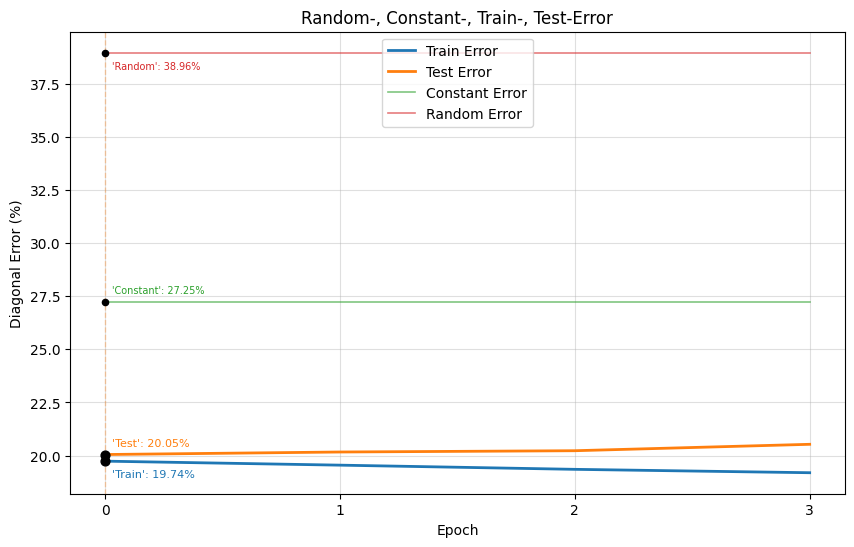

In [23]:
# ============================================================
# Plot: Test Error for all Learning Rates
# ============================================================

if globals().get("bas_const_err") is None:
    bas_const_err = 30.99

if globals().get("bas_rand_err") is None:
    bas_rand_err = 42.70


# ============================================================
# Colors
# ============================================================

# Die Farbe
train_color = "tab:blue"
test_color = "tab:orange"
const_color = "tab:green"
rand_color = "tab:red"
point_color = "black"

# ============================================================
# Extract results
# ============================================================

train_errors = norm_results["train_errors"]
test_errors = norm_results["test_errors"]


print(f"\n\n Diagonal-Train-Error: {np.float64(train_errors)}\n")
print(f" Diagonal-Test-Error: {np.float64(test_errors)}\n\n")

print(f" Diagonal-Train-Error-Max: {np.max(train_errors)} \t Diagonal-Train-Error-Min: {np.min(train_errors)}\t")
# print(f" Diagonal-Train-Error-Ave: {np.mean(diag_train_error)}\n")

print(f" Diagonal-Test-Error-Max: {np.max(test_errors)}\t Diagonal-Test-Error-Min: {np.min(test_errors)}\t\n\n")
# print(f" Diagonal-Test-Error-Ave: {np.mean(diag_test_error)}\n")

# Epochs start at 0 if the initial evaluation is included.
# Otherwise, use range(1, len(test_errors) + 1).
epochs_axis = range(len(test_errors))

max_epochs = len(test_errors)
epochs_baseline = range(max_epochs)


# Curven:

# Minimum Test Error bestimmen
min_test_error = min(test_errors)
min_test_epoch = test_errors.index(min_test_error) + 1

# Die vier Werte an dieser Epoch
train_at_min = train_errors[min_test_epoch - 1]
test_at_min = test_errors[min_test_epoch - 1]
const_at_min = bas_const_err
rand_at_min = bas_rand_err

print(
    "\n",
    f"min_test_epoch:     {min_test_epoch} \n"
    f"train_min:          {train_at_min} \n"
    f"test_min:           {test_at_min} \n"
)

# ============================================================
# Best test error
# ============================================================

best_test_error = norm_results["best_test_error"]

min_test_epoch = int(np.argmin(test_errors))


# ============================================================
# Figure
# ============================================================

plt.figure(figsize=(10, 6))


# ============================================================
# Train Error Curve
# ============================================================

plt.plot(
    epochs_axis,
    train_errors,
    linestyle="-",
    linewidth=2,
    color=train_color,
    label="Train Error"
)


# ============================================================
# Test Error Curve
# ============================================================

plt.plot(
    epochs_axis,
    test_errors,
    linestyle="-",
    # marker="o",
    markersize=3,
    linewidth=2,
    color=test_color,
    label="Test Error"
)


# ============================================================
# Point at minimum test error
# ============================================================


# Punkt beim Minimum des Test Errors
plt.scatter(
    min_test_epoch,
    min_test_error,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Min Test Error ({min_test_error:.2f}%)"
)

plt.scatter(
    min_test_epoch,
    train_at_min,
    s=40,
    zorder=5,
    color=point_color
    # label=f"Train at min_Test_Error ({train_at_min_test:.2f}%)"
)


# --------------------------------------------------------
# Vertical line through minimum
# --------------------------------------------------------

plt.axvline(
    x=min_test_epoch,
    linestyle="--",
    linewidth=1.0,
    alpha=0.35,
    color=test_color
)


# --------------------------------------------------------
# Annotation
# --------------------------------------------------------


# Werte an der vertikalen Linie anzeigen
plt.annotate(
    f"'Train': {train_at_min:.2f}%",
    xy=(min_test_epoch, train_at_min),
    xytext=(5, -12),
    textcoords="offset points",
    color=train_color,
    fontsize=8
)

plt.annotate(
    f"'Test': {test_at_min:.2f}%",
    xy=(min_test_epoch, test_at_min),
    xytext=(5, 6),
    textcoords="offset points",
    color=test_color,
    fontsize=8,
)


# ============================================================
# Baselines
# ============================================================

epochs_baseline = range(0, len(test_errors))


# Constant baseline
plt.plot(
    epochs_baseline,
    [bas_const_err] * len(epochs_baseline),
    label="Constant Error",
    linestyle="-",
    linewidth=1.2,
    alpha=0.6,
    color=const_color
)


# Random baseline
plt.plot(
    epochs_baseline,
    [bas_rand_err] * len(epochs_baseline),
    label="Random Error",
    linestyle="-",
    linewidth=1.2,
    alpha=0.6,
    color=rand_color
)

plt.scatter(
    min_test_epoch,
    const_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.scatter(
    min_test_epoch,
    rand_at_min,
    s=20,
    zorder=4,
    color=point_color
)

plt.annotate(
    f"'Constant': {const_at_min:.2f}%",
    xy=(min_test_epoch, const_at_min),
    xytext=(5, 6),
    textcoords="offset points",
    color=const_color,
    fontsize=7
)

plt.annotate(
    f"'Random': {rand_at_min:.2f}%",
    xy=(min_test_epoch, rand_at_min),
    xytext=(5, -12),
    textcoords="offset points",
    color=rand_color,
    fontsize=7
)


# ============================================================
# Labels and title
# ============================================================


plt.title("Random-, Constant-, Train-, Test-Error")


plt.xlabel("Epoch")

plt.ylabel("Diagonal Error (%)")


# ============================================================
# X-axis
# ============================================================

plt.xticks(
    range(len(epochs_baseline))
)


# ============================================================
# Y-axis
# ============================================================

# plt.yticks(
#     range(19, 40)
# )

# ============================================================
# Grid and legend
# ============================================================

plt.grid(
    True,
    alpha=0.4
)

plt.legend()


# ============================================================
# Save figure
# ============================================================

# os.makedirs(
#     "./results",
#     exist_ok=True
# )


# plt.savefig(
#     f"results/"
#     f"test_error_learning_rates_"
#     f"{def_dataset}_"
#     f"{def_dataset_size[0]}_"
#     f"{def_dataset_size[1]}_"
#     f"batch{batch_Size}_"
#     f"{act}.png",
#     dpi=300,
#     bbox_inches="tight"
# )


plt.show()

In [59]:
# ---------- Evaluation ----------

saved_model = "./models/best_models/best_ResNet_Sigmoid.path"

# norm_subject:
saved_model1 = "./models/best_models/best_ResNet_Sigmoid_norm_subject.path"

# norm_random:
saved_model2 = "./models/best_models/best_ResNet_Sigmoid_norm_random.path"

checkpoint = torch.load(
    saved_model2,
    map_location=device
)

model.load_state_dict(checkpoint)

model.to(device)

model.eval()


print(f"Test:\n")
test_mae, test_rmse, test_diag_pct = diagonal_errors(model, test_loader, device)

print(
        f"test_diag_error={test_diag_pct:.4f}% "
    )


targets, predictions, errors = evaluate_model(
    model,
    test_loader,
    device
)

results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


# results_df.to_csv(
#     "results/heatmap/base_loss2_2.csv",
#     index=False
# )

# results_df.to_csv(
#     f"results/heatmap/base_loss1_2_{def_dataset}.csv",
#     index=False
# )

results_df.to_csv(
    f"results/heatmap/base_loss1_{def_dataset}.csv",
    index=False
)


Test:

MAE : 0.2208 	 RMSE: 0.2664 
Diagonal-Error %: 18.8366 %
test_diag_error=18.8366% 


In [ ]:
import pandas as pd


results_df = pd.DataFrame({
    "gt_x": targets[:, 0],
    "gt_y": targets[:, 1],
    "pred_x": predictions[:, 0],
    "pred_y": predictions[:, 1]
})


results_df.to_csv(
    "results/heatmap/bas_predictions_loss2.csv",
    index=False
)



	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 10000, 	 test: 2000
	 batch_Size: 	 32
	 def_dataset: 	 norm_subject
	 learning_rate: 	 0.0001
	 epochs: 	 500
	 patience: 	 3

	 t: 1
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.layer4.parameters: False
param in model.fc.parameters: True
param in model.fc.parameters: True
param in model.fc.parameters: True
param in model.fc.parameters: True
param in model.fc.parameters: True
param in model.fc.parameters

Epoch 1: 100%|█████████████████████████████████████████████████████████████████████| 313/313 [08:31<00:00,  1.63s/it, loss=0.235]



train_error:
MAE : 0.2339 	 RMSE: 0.2745 
Diagonal-Error %: 19.4108 %

test_error:
MAE : 0.2345 	 RMSE: 0.2785 
Diagonal-Error %: 19.6916 %
Test-Diagonal-Error: 19.6916% | Improvment: 2

[19:40:33] Epoch 1: 1071.67 Sekunden | Running_loss: 0.235 | test_diag_error=19.6916% | train_diag_error=19.4108% | 



Epoch 2: 100%|█████████████████████████████████████████████████████████████████████| 313/313 [07:50<00:00,  1.50s/it, loss=0.267]



train_error:
MAE : 0.2331 	 RMSE: 0.2736 
Diagonal-Error %: 19.3481 %

test_error:
MAE : 0.2348 	 RMSE: 0.2785 
Diagonal-Error %: 19.6917 %
Patience: 1/3

[19:57:25] Epoch 2: 1011.67 Sekunden | Running_loss: 0.234 | test_diag_error=19.6917% | train_diag_error=19.3481% | 



...


train_error:
MAE : 0.2337 	 RMSE: 0.2741 
Diagonal-Error %: 19.3844 %

test_error:
MAE : 0.2345 	 RMSE: 0.2787 
Diagonal-Error %: 19.7062 %
Patience: 1/3

[00:44:04] Epoch 2: 978.02 Sekunden | Running_loss: 0.234 | test_diag_error=19.7062% | train_diag_error=19.3844% | 



Epoch 3: 100%|█████████████████████████████████████████████████████████████████████| 313/313 [07:36<00:00,  1.46s/it, loss=0.213]



train_error:
MAE : 0.2319 	 RMSE: 0.2725 
Diagonal-Error %: 19.2673 %

test_error:
MAE : 0.2349 	 RMSE: 0.2784 
Diagonal-Error %: 19.6882 %
Patience: 2/3

[01:00:20] Epoch 3: 975.94 Sekunden | Running_loss: 0.234 | test_diag_error=19.6882% | train_diag_error=19.2673% | 



Epoch 4: 100%|█████████████████████████████████████████████████████████████████████| 313/313 [07:37<00:00,  1.46s/it, loss=0.228]



train_error:
MAE : 0.2301 	 RMSE: 0.2719 
Diagonal-Error %: 19.2241 %

test_error:
MAE : 0.2356 	 RMSE: 0.2794 
Diagonal-Error %: 19.7576 %
Patience: 3/3

Early Stopping after 4 Epochen.
Imporovments totally: 2

totll running-tiems (s): 4448.34 Sekunden
totll running-tiems (min): 74.14 Minuten

last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 74.14 min	 | improvements: 2 Epochen	 | best_test_error: 19.6562 % 

  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=
  =#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#==#=


 Parameter:
 best_test_error: [19.69159 19.67359 19.69785 19.69303 19.65619], 
 running_time: [78.83583934 76.00137809 59.62526972 76.32883505 74.13899965] 



	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 10000, 	 test: 2000
	 batch_Size: 	 32
	 def_dataset: 	 norm_subject
	 learning_rate: 	 0.0001
	 epochs: 	 500
	 patience: 	 3

     param in model.layer4.parameters: False
     param in model.fc.parameters: True

# def_dataset_size: train: 10000, 	 test: 2000
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 78.84 min	 | improvements: 2 Epochen	 | best_test_error: 19.6916 % 
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 76.00 min	 | improvements: 2 Epochen	 | best_test_error: 19.6736 %
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 59.63 min	 | improvements: 1 Epochen	 | best_test_error: 19.6978 % 
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 76.33 min	 | improvements: 2 Epochen	 | best_test_error: 19.6930 % 
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 74.14 min	 | improvements: 2 Epochen	 | best_test_error: 19.6562 %

best_test_error =  [19.69159, 19.67359, 19.69785, 19.69303, 19.65619] 
running_time    =  [78.84, 76.00, 59.63, 76.33, 74.14] 

################################################################################################################################
################################################################################################################################

	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 32
	 def_dataset: 	 norm_subject
	 learning_rate: 	 0.0001
	 epochs: 	 500
	 patience: 	 3
     
     param in model.layer4.parameters: False
     param in model.fc.parameters: True
     
# def_dataset_size: train: 1000, 	 test: 200
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 7.06 min	 | improvements: 1 Epochen	 | best_test_error: 20.0895 % 
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 7.91 min	 | improvements: 2 Epochen	 | best_test_error: 20.0419 %
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 7.48 min	 | improvements: 2 Epochen	 | best_test_error: 20.0626 % 
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 5.75 min	 | improvements: 1 Epochen	 | best_test_error: 20.1050 %
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 7.63 min	 | improvements: 2 Epochen	 | best_test_error: 20.0442 % 



best_test_error = [20.08953, 20.04193, 20.06257, 20.10499, 20.04419]
running_time    = [7.06, 7.91, 7.48, 5.75, 7.63]



In [ ]:
# dataset_size: 1000 & 200
best_test_error = [20.08953, 20.04193, 20.06257, 20.10499, 20.04419]
running_time    = [7.06, 7.91, 7.48, 5.75, 7.63]

# dataset_size: 10000 & 2000
best_test_error =  [19.69159, 19.67359, 19.69785, 19.69303, 19.65619] 
running_time    =  [78.84, 76.00, 59.63, 76.33, 74.14] 

In [ ]:
# FC + lay 4:
best_test_error =  [19.95091, 20.2972, 20.07323, 20.04155, 20.19138]
running_time    =  [7.626, 10.104, 7.248, 7.389, 7.081]

# FC only:
best_test_error = [20.08953, 20.04193, 20.06257, 20.10499, 20.04419], 
running_time    = [7.057, 7.908 7.478, 5.753, 7.628]

In [49]:

test_error_parm, run_time_parm = [], []
for i in range(len(parameter)):
    if i % 2 == 0:
        test_error_parm.append((np.round(parameter[i], 5)))
    else:
        run_time_parm.append(np.round(parameter[i], 3))

print(f"\n test_error_parm: {np.float64(test_error_parm)} \n run_time_parm: {np.float64(run_time_parm)}\n\n")


parameter2 = []

parm_test_error = []
parm_run_time = []

for act, values in act_time_epochs.items():
    print(
        f"last_layer: {act}\t"
        f" epochs: {values['epochs']} Epochen\t|"
        f" running_time: {values['time_minutes']:.2f} min\t |"
        f" improvements: {values['improvements']} Epochen\t |"
        f" best_test_error: {values['best_test_error']:.4f} % "
    )
    parameter2.append(float(f"{values['best_test_error']:.4f}"))
    parm_test_error.append(float(f"{values['best_test_error']:.4f}"))
    parm_run_time.append(float(f"{values['time_minutes']:.2f}"))

print(f"\n parameter2: {parameter2}")
print(f"\n parameter: {np.float64([np.float64(parameter[p]) for p in range(len(parameter))])}")
print(f"\n run_time: {parm_run_time}")
print(f"\n test_error: {parm_test_error}")


 test_error_parm: [20.19735 20.17375 19.98697 20.11189 20.06467] 
 run_time_parm: [10.507 11.879  6.817 11.947  6.362]


last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 6.36 min	 | improvements: 1 Epochen	 | best_test_error: 20.0647 % 

 parameter2: [20.0647]

 parameter: [20.19735    10.50747222 20.17375    11.87886853 19.98697     6.81678813
 20.11189    11.94715597 20.06467     6.36239556]

 run_time: [6.36]

 test_error: [20.0647]


    dataset_name: 	  norm_labels.csv
    def_dataset_size: train: 1000, 	 test: 200
    batch_Size: 	  128
    dataset-splits:   norm_subject
    learning_rate: 	  0.0001
    epochs: 	      500
    patience: 	      3

## batch_size(32 vs. 64 vs. 132):
 * dataset_name: 	   norm_labels.csv
 * dataset_size:       train: 1000, 	 test: 200
 * dataset-splits: 	   norm_subject
 * batch_Size: 	       32 vs. 64 vs. 132      <============
 * learning_rate: 	   1e-4

	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 32
	 def_dataset: 	 norm_subject
	 learning_rate: 	 1e-05
	 epochs: 	 500
	 patience: 	 3

# batch_size: 	 32
 
* ** try 1 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 7.44 min	 | improvements: 2 Epochen	 | best_test_error: 20.0913 % 

* ** try 2 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 7.34 min	 | improvements: 2 Epochen	 | best_test_error: 20.0092 %  

* ** try 3 **:
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 6.07 min	 | improvements: 1 Epochen	 | best_test_error: 20.0785 %

* ** try 4 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 8.69 min	 | improvements: 2 Epochen	 | best_test_error: 20.0367 % 

* ** try 5 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 8.65 min	 | improvements: 2 Epochen	 | best_test_error: 20.0945 %

########################################################################
	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 64
	 def_dataset: 	 norm_subject
	 learning_rate: 	 1e-05
	 epochs: 	 500
	 patience: 	 3

# batch_size: 	 64

* ** try 1 **:
last_layer: Sigmoid	 epochs: 5 Epochen	| running_time: 10.26 min	 | improvements: 3 Epochen	 | best_test_error: 20.2225 % 

* ** try 2 **:
last_layer: Sigmoid	 epochs: 7 Epochen	| running_time: 14.27 min	 | improvements: 5 Epochen	 | best_test_error: 20.2962 %

* ** try 3 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 8.27 min	 | improvements: 2 Epochen	 | best_test_error: 20.1555 %

* ** try 4 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 8.08 min	 | improvements: 2 Epochen	 | best_test_error: 19.9577 %

* ** try 5 **:
last_layer: Sigmoid	 epochs: 5 Epochen	| running_time: 10.08 min	 | improvements: 3 Epochen	 | best_test_error: 19.9995 %

########################################################################
	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 128
	 def_dataset: 	 norm_subject
	 learning_rate: 	 1e-05
	 epochs: 	 500
	 patience: 	 3

# batch_size: 	 128
 
* ** try 1 **:
last_layer: Sigmoid	 epochs: 5 Epochen	| running_time: 10.51 min	 | improvements: 3 Epochen	 | best_test_error: 20.1974 %

* ** try 2 **:
last_layer: Sigmoid	 epochs: 6 Epochen	| running_time: 11.88 min	 | improvements: 4 Epochen	 | best_test_error: 20.1737 % 

* ** try 3 **:
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 6.82 min	 | improvements: 1 Epochen	 | best_test_error: 19.9870 %

* ** try 4 **:
last_layer: Sigmoid	 epochs: 6 Epochen	| running_time: 11.95 min	 | improvements: 4 Epochen	 | best_test_error: 20.1119 %

* ** try 5 **:
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 6.36 min	 | improvements: 1 Epochen	 | best_test_error: 20.0647 %


In [51]:
parm_bat32_te = [20.0913, 20.0092, 20.0785, 20.0367, 20.0945]
parm_bat32_rt = [7.44, 7.34, 6.07, 8.69, 8.65]

parm_bat64_te = [20.2225, 20.2962, 20.1555, 19.9577, 19.9995]
parm_bat64_rt = [10.26, 14.27, 8.27, 8.08, 10.08]

parm_bat128_te = [20.19735, 20.17375, 19.98697, 20.11189, 20.06467]
parm_bat128_rt = [10.507, 11.879, 6.817, 11.947, 6.362]


In [59]:
# parm_bat_32: 

# parm_bat32_te = [20.0913, 20.0092, 20.0785, 20.0367, 20.0945]
# parm_bat32_rt = [7.44, 7.34, 6.07, 8.69, 8.65]

parm_test_error   = parm_bat32_te
parm_running_time = parm_bat32_rt


print('\n\n')
print('#'*60)
print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')
print('#'*60)

conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time: \t\t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)




############################################################
###############	 Confidence Intervall: ###############
############################################################

 Test-Error : 		 Mean = 20.06204, 
	 Confidence interval 0.98% = [19.99926, 20.12482]

 Running-Time: 		 Mean = 7.638, 
	 Confidence interval 0.98%:  [5.818, 9.458]




In [61]:
# parm_bat_128:

# parm_bat128_te = [20.19735, 20.17375, 19.98697, 20.11189, 20.06467]
# parm_bat128_rt = [10.507, 11.879, 6.817, 11.947, 6.362]


parm_test_error   = parm_bat64_te
parm_running_time = parm_bat64_rt

print('\n\n')
print('#'*60)
print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')
print('#'*60)

conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time: \t\t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)




############################################################
###############	 Confidence Intervall: ###############
############################################################

 Test-Error : 		 Mean = 20.12628, 
	 Confidence interval 0.98% = [19.88421, 20.36835]

 Running-Time: 		 Mean = 10.192, 
	 Confidence interval 0.98%:  [6.019, 14.365]




In [62]:
# parm_bat_128:

parm_test_error   = parm_bat128_te
parm_running_time = parm_bat128_rt
print('\n\n')
print('#'*60)
print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')
print('#'*60)

conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time: \t\t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)




############################################################
###############	 Confidence Intervall: ###############
############################################################

 Test-Error : 		 Mean = 20.10693, 
	 Confidence interval 0.98% = [19.96464, 20.24922]

 Running-Time: 		 Mean = 9.502, 
	 Confidence interval 0.98%:  [4.936, 14.069]




In [ ]:
parm_bat32_te = [20.0913, 20.0092, 20.0785, 20.0367, 20.0945]
parm_bat32_rt = [7.44, 7.34, 6.07, 8.69, 8.65]

parm_bat64_te = [20.2225, 20.2962, 20.1555, 19.9577, 19.9995]
parm_bat64_rt = [10.26, 14.27, 8.27, 8.08, 10.08]

parm_bat128_te = [20.19735, 20.17375, 19.98697, 20.11189, 20.06467]
parm_bat128_rt = [10.507, 11.879, 6.817, 11.947, 6.362]


# 32:
 Test-Error : 		 Mean = 20.06204, 
	 Confidence interval 0.98% = [19.99926, 20.12482]
# 64:
 Test-Error : 		 Mean = 20.12628, 
	 Confidence interval 0.98% = [19.88421, 20.36835]
# 128:
 Test-Error : 		 Mean = 20.10693, 
	 Confidence interval 0.98% = [19.96464, 20.24922]


# 32:
 Running-Time: 		 Mean = 7.638, 
	 Confidence interval 0.98%:  [5.818, 9.458]
# 64:
 Running-Time: 		 Mean = 10.192, 
	 Confidence interval 0.98%:  [6.019, 14.365]
# 128:
 Running-Time: 		 Mean = 9.502, 
	 Confidence interval 0.98%:  [4.936, 14.069]


## def_dataset(norm_subject, norm_random):
 * dataset_name: 	   norm_labels.csv
 * dataset_size:       train: 1000, 	 test: 200
 * dataset-splits: 	   norm_subject vs. norm_random      <============
 * batch_Size: 	       128
 * learning_rate: 	   1e-4

	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 128
	 def_dataset: 	 norm_subject
	 learning_rate: 	 0.0001
	 epochs: 	 500
	 patience: 	 3

# dataset-splits: 	 norm_subject
 
* ** try 1 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.30 min	 | improvements: 2 Epochen	 | best_test_error: 20.1205 % 

* ** try 2 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.25 min	 | improvements: 2 Epochen	 | best_test_error: 20.0771 % 

* ** try 3 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.22 min	 | improvements: 2 Epochen	 | best_test_error: 20.0507 %

* ** try 4 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.04 min	 | improvements: 2 Epochen	 | best_test_error: 20.0485 % 

* ** try 5 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.21 min	 | improvements: 2 Epochen	 | best_test_error: 20.0101 % 

* ** try 6 **:
last_layer: Sigmoid	 epochs: 5 Epochen	| running_time: 11.28 min	 | improvements: 3 Epochen	 | best_test_error: 19.9546 %

parm_norm_sub_te = [20.1205, 20.0771, 20.0507, 20.0485, 20.0101, 19.9546]
parm_norm_sub_rt = [9.30, 9.25, 9.22, 9.04, 9.21, 11.28]


########################################################################
# dataset-splits: 	 norm_random

* ** try 1 **:
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 7.24 min	 | improvements: 1 Epochen	 | best_test_error: 18.8797 %

* ** try 2 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.14 min	 | improvements: 2 Epochen	 | best_test_error: 18.8308 %

* ** try 3 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.24 min	 | improvements: 2 Epochen	 | best_test_error: 18.8890 %

* ** try 4 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 8.98 min	 | improvements: 2 Epochen	 | best_test_error: 18.8544 %

* ** try 5 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.72 min	 | improvements: 2 Epochen	 | best_test_error: 18.9156 %

* ** try 6 **:
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 9.17 min	 | improvements: 2 Epochen	 | best_test_error: 18.8534 %


parm_norm_random_te = [18.8797, 18.8308, 18.8890, 18.8544, 18.9156, 18.8534]
parm_norm_random_rt = [7.24, 9.14, 9.24, 8.98, 9.72, 9.17]

In [70]:

parm_norm_sub_te = [20.1205, 20.0771, 20.0507, 20.0485, 20.0101, 19.9546]
parm_norm_sub_rt = [9.30, 9.25, 9.22, 9.04, 9.21, 11.28]

parm_norm_random_te = [18.8797, 18.8308, 18.8890, 18.8544, 18.9156, 18.8534]
parm_norm_random_rt = [7.24, 9.14, 9.24, 8.98, 9.72, 9.17]

## dataset_size:((10000, 2000) vs. (1000, 200)):
 * dataset_name: 	   norm_labels.csv
 * dataset_size:       (10000, 2000) vs. (1000, 200)    <============  
 * dataset-splits: 	   norm_subject
 * batch_Size: 	       32
 * learning_rate: 	   1e-4   

# Dataset_size : 10000 & 2000 vs 1000 & 200


In [26]:
# Dataset_size: 10000 & 2000
dataset_size1 = [19.69159, 19.67359, 19.69785, 19.69303, 19.65619]           # 10000: train & 2000: test 
running_time1  = [78.84, 76.00, 59.63, 76.33, 74.14]


# Dataset_size: 1000 & 200
dataset_size2 = [20.08953, 20.04193, 20.06257, 20.10499, 20.04419]           # 1000:  train & 200:  test
running_time2 = [7.06, 7.91, 7.48, 5.75, 7.63]


test_error1 = dataset_size1
test_error2 = dataset_size2

run_time1 = running_time1
run_time2 = running_time2

###############	 Confidence Intervall: ###############

parm_test_error   = test_error1
parm_running_time = run_time1


thema = "Dataset_size = 10000 & 2000"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)



###############	 Confidence Intervall: ###############

parm_test_error   = test_error2
parm_running_time = run_time2


thema = "Dataset_size = 1000 & 200"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error2 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time2 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)




  Thema: 	 Dataset_size = 10000 & 2000 

###############	 Confidence Intervall: 	####################

 Test-Error1 : 		 Mean = 19.68245, 
	 Confidence interval 0.98% = [19.65342, 19.71148]

 Running-Time1 : 	 Mean = 72.988, 
	 Confidence interval 0.98%:  [60.165, 85.811]




  Thema: 	 Dataset_size = 1000 & 200 

###############	 Confidence Intervall: 	####################

 Test-Error2 : 		 Mean = 20.06864, 
	 Confidence interval 0.98% = [20.02195, 20.11533]

 Running-Time2 : 	 Mean = 7.166, 
	 Confidence interval 0.98%:  [5.743, 8.589]




# trainable model layers: layer 4 & FC vs. only FC

In [18]:
# FC + lay 4:
test_error1  =  [19.95091, 20.2972, 20.07323, 20.04155, 20.19138]
run_time1    =  [7.626, 10.104, 7.248, 7.389, 7.081]

# FC only:
test_error2  = [20.08953, 20.04193, 20.06257, 20.10499, 20.04419]
run_time2    = [7.057, 7.908, 7.478, 5.753, 7.628]


###############	 Confidence Intervall: ###############

parm_test_error   = test_error1
parm_running_time = run_time1


thema = "trainable model-layers: layer 4 & fc"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}% =  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)



###############	 Confidence Intervall: ###############

parm_test_error   = test_error2
parm_running_time = run_time2


thema = "trainable model-layers: only fc"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error2 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time2 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}% =  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


################### trainable model-layers: layer 4 & fc 
# Test-Error1 : 		 
Mean = 20.11085, 
Confidence interval 0.98% = [19.88447, 20.33724]

# Running-Time1 : 	 
Mean = 7.890, 
Confidence interval 0.98% =  [5.788, 9.991]


################## trainable model-layers: only fc 
# Test-Error2 : 		 
Mean = 20.06864 
Confidence interval 0.98% = [20.02195, 20.11533]

# Running-Time2 : 	 
Mean = 7.165 
Confidence interval 0.98% =  [5.745, 8.584]



  Thema: 	 trainable model-layers: layer 4 & fc 

###############	 Confidence Intervall: 	####################

 Test-Error1 : 		 Mean = 20.11085, 
	 Confidence interval 0.98% = [19.88447, 20.33724]

 Running-Time1 : 	 Mean = 7.890, 
	 Confidence interval 0.98%:  [5.788, 9.991]




  Thema: 	 trainable model-layers: only fc 

###############	 Confidence Intervall: 	####################

 Test-Error2 : 		 Mean = 20.06864, 
	 Confidence interval 0.98% = [20.02195, 20.11533]

 Running-Time2 : 	 Mean = 7.165, 
	 Confidence interval 0.98%:  [5.745, 8.584]




In [ ]:
 dataset_name: 	 norm_labels.csv

 def_dataset_size: train: 1000, 	 test: 200

 batch_Size: 	 32

 def_dataset: 	 norm_subject

 learning_rate: 	 0.0001

In [42]:
# loss 1:
test_error1 = [20.0098, 	20.2339, 	20.0127, 	20.2048, 	20.1970]
run_time1 = [8.15, 		8.67, 		9.12, 		15.50, 		10.61]

# loss 2 (loss_sensetive)
test_error2 = [20.1656, 	20.2252, 	20.1940, 	20.1018, 	20.1746]
run_time2 = [14.84, 		9.96, 		13.57, 		11.91, 		8.09]



###############	 Confidence Intervall: ###############

parm_test_error   = test_error1
parm_running_time = run_time1


thema = "loss_func = loss1"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)



###############	 Confidence Intervall: ###############

parm_test_error   = test_error2
parm_running_time = run_time2


thema = "loss_func = loss2(loss_sensetive)"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error2 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time2 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


############### loss_func = loss1 
# Test-Error1 : 		 
Mean = 20.13164, 
Confidence interval 0.98 % = [19.94604, 20.31724]

# Running-Time1 : 	 
Mean = 10.410
Confidence interval 0.98 % =  [5.401, 15.419]



############### loss_func = loss2(loss_sensetive) 
# Test-Error2 : 		 
Mean = 20.17224 
Confidence interval 0.98% = [20.09596, 20.24852]

# Running-Time2 : 	 
Mean = 11.674
Confidence interval 0.98%:  [7.127, 16.221]

SyntaxError: invalid decimal literal (1353200851.py, line 86)

======================================================================
Learning Rate Experiment
======================================================================
	 Dataset:          norm_labels.csv
	 Dataset size:     train=1000, test=200
	 Batch size:       32
	 Dataset split:    norm_subject
	 Activation:       Sigmoid
	 Learning rates:   [0.001, 0.0001, 1e-05, 1e-06]
	 Epochs:           500
	 Patience:         3
	 Runs:             1
	 Trainable layers: FC only
======================================================================

======================================================================
LEARNING RATE RESULTS
======================================================================
# try 1: 
LR=1e-03 | Best Test Error=20.1291% | Time=2.41 min  | Epochs=3
LR=1e-04 | Best Test Error=20.1922% | Time=2.49 min  | Epochs=3
LR=1e-05 | Best Test Error=20.1607% | Time=2.64 min  | Epochs=3
LR=1e-06 | Best Test Error=20.1135% | Time=3.56 min  | Epochs=4

# try 2:
LR=1e-03 | Best Test Error=19.9910% | Time=2.40 min  | Epochs=3
LR=1e-04 | Best Test Error=19.9891% | Time=5.76 min  | Epochs=7
LR=1e-05 | Best Test Error=20.0767% | Time=8.51 min  | Epochs=10
LR=1e-06 | Best Test Error=19.9743% | Time=3.58 min  | Epochs=4

# try 3:
LR=1e-03 | Best Test Error=19.9670% | Time=3.29 min  | Epochs=4
LR=1e-04 | Best Test Error=19.9685% | Time=3.49 min  | Epochs=4
LR=1e-05 | Best Test Error=20.1116% | Time=5.15 min  | Epochs=6
LR=1e-06 | Best Test Error=20.0302% | Time=7.68 min  | Epochs=9

# try 4:
LR=1e-03 | Best Test Error=20.0252% | Time=3.22 min  | Epochs=4
LR=1e-04 | Best Test Error=20.0602% | Time=2.54 min  | Epochs=3
LR=1e-05 | Best Test Error=20.0178% | Time=2.68 min  | Epochs=3
LR=1e-06 | Best Test Error=20.1123% | Time=24.52 min | Epochs=28

# try 5:
LR=1e-03 | Best Test Error=20.2964% | Time=2.45 min | Epochs=3
LR=1e-04 | Best Test Error=20.0719% | Time=3.44 min | Epochs=4
LR=1e-05 | Best Test Error=20.1138% | Time=4.46 min | Epochs=5
LR=1e-06 | Best Test Error=20.1348% | Time=2.74 min | Epochs=3


# ############################################################
# Learning rate: 1e-3
LR=1e-03 | Best Test Error=20.1291% | Time=2.41 min  | Epochs=3
LR=1e-03 | Best Test Error=19.9910% | Time=2.40 min  | Epochs=3
LR=1e-03 | Best Test Error=19.9670% | Time=3.29 min  | Epochs=4
LR=1e-03 | Best Test Error=20.0252% | Time=3.22 min  | Epochs=4
LR=1e-03 | Best Test Error=20.2964% | Time=2.45 min  | Epochs=3


TE_LR_3 = [20.1291, 19.9910, 19.9670, 20.0252, 20.2964]
RT_LR_3 = [2.41, 2,40, 3.29, 3.22, 2.45]

# ############################################################
# Learning rate: 1e-4
LR=1e-04 | Best Test Error=20.1922% | Time=2.49 min  | Epochs=3
LR=1e-04 | Best Test Error=19.9891% | Time=5.76 min  | Epochs=7
LR=1e-04 | Best Test Error=19.9685% | Time=3.49 min  | Epochs=4
LR=1e-04 | Best Test Error=20.0602% | Time=2.54 min  | Epochs=3
LR=1e-04 | Best Test Error=20.0719% | Time=3.44 min  | Epochs=4


TE_LR_4 = [20.1922, 19.9891, 19.9685, 20.0602, 20.0719]
RT_LR_4 = [2.49, 5.76, 3.49, 2.54, 3.44]

# ############################################################
# Learning rate: 1e-5
LR=1e-05 | Best Test Error=20.1607% | Time=2.64 min  | Epochs=3
LR=1e-05 | Best Test Error=20.0767% | Time=8.51 min  | Epochs=10
LR=1e-05 | Best Test Error=20.1116% | Time=5.15 min  | Epochs=6
LR=1e-05 | Best Test Error=20.0178% | Time=2.68 min  | Epochs=3
LR=1e-05 | Best Test Error=20.1138% | Time=4.46 min  | Epochs=5

TE_LR_5 = [20.1607, 20.0767, 20.1116, 20.0178, 20.1138]
RT_LR_5 = [2.64, 8.51, 5.15, 2.68, 4.46]

# ############################################################
# Learning rate: 1e-6
LR=1e-06 | Best Test Error=20.1135% | Time=3.56 min  | Epochs=4
LR=1e-06 | Best Test Error=19.9743% | Time=3.58 min  | Epochs=4
LR=1e-06 | Best Test Error=20.0302% | Time=7.68 min  | Epochs=9
LR=1e-06 | Best Test Error=20.1123% | Time=24.52 min | Epochs=28
LR=1e-06 | Best Test Error=20.1348% | Time=2.74 min  | Epochs=3


TE_LR_6 = [20.1135, 19.9743, 20.0302, 20.1123, 20.1348]
RT_LR_6 = [3.56, 3.58, 7.68, 24.52, 2.74]


In [90]:
"""     
     dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 128
	 def_dataset: 	 norm_subject
	 learning_rate: 	 XXXXXXXXXXXXXXXXXXX
	 epochs: 	 500
	 patience: 	 3

"""

# 1e-3:

best_test_error_3 = [20.08309, 20.07633, 20.14909, 20.1672, 20.12841]
running_time_3    = [6.39,     7.94,     6.29,     6.99,    7.01]

########################################################################
# 1e-4:

best_test_error_4 = [20.03305, 20.00925, 20.0298, 20.04046, 19.99575] 
running_time_4    = [9.125,    9.68,     6.48,    8.37,     6.49] 
########################################################################
# 1e-5:

best_test_error_5 = [20.08512, 20.10841, 20.11687, 20.10085, 20.11486] 
running_time_5    = [8.31,     12.15,    12.055, 6.50,          8.39]

########################################################################
# 1e-6:

best_test_error_6 = [20.32283, 20.0783, 20.05378, 20.33607, 20.36392]
running_time_6    = [6.50,     17.73,   19.66,    8.37,     6.50]


######################################################
###############	 Confidence Intervall: ###############
######################################################

parm_test_error   = best_test_error_3

parm_running_time = running_time_3


thema = "lr = 1e-3"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

parm_test_error   = best_test_error_4
parm_running_time = running_time_4


thema = "lr = 1e-4"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

parm_test_error   = best_test_error_5
parm_running_time = running_time_5


thema = "lr = 1e-5"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

parm_test_error   = best_test_error_6
parm_running_time = running_time_6

thema = "lr = 1e-6"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)

############### lr = 1e-3 
# Test-Error1 : 		 
Mean = 20.12082
Confidence interval 0.98% = [20.05374, 20.18791]

# Running-Time1 : 	 
Mean = 6.924, 
Confidence interval 0.98% =  [5.822, 8.026]


############### lr = 1e-4 
# Test-Error1 : 		 
Mean = 20.02166
Confidence interval 0.98% = [19.99060, 20.05273]

# Running-Time1 : 	 
Mean = 8.029 
Confidence interval 0.98% =  [5.542, 10.516]


############### lr = 1e-5 
# Test-Error1 : 		 
Mean = 20.10522
Confidence interval 0.98% = [20.08367, 20.12678]

# Running-Time1 : 	 
Mean = 9.481 
Confidence interval 0.98% =  [5.275, 13.687]


############### lr = 1e-6 
# Test-Error1 : 		 
Mean = 20.23098
Confidence interval 0.98% = [19.97704, 20.48492]

# Running-Time1 : 	 
Mean = 11.752, 
Confidence interval 0.98% =  [0.994, 22.510]




  Thema: 	 lr = 1e-3 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.12082, 
	 Confidence interval 0.98% = [20.05374, 20.18791]

 Running-Time1 : 	 Mean = 6.924, 
	 Confidence interval 0.98%:  [5.822, 8.026]




  Thema: 	 lr = 1e-4 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.02166, 
	 Confidence interval 0.98% = [19.99060, 20.05273]

 Running-Time1 : 	 Mean = 8.029, 
	 Confidence interval 0.98%:  [5.542, 10.516]




  Thema: 	 lr = 1e-5 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.10522, 
	 Confidence interval 0.98% = [20.08367, 20.12678]

 Running-Time1 : 	 Mean = 9.481, 
	 Confidence interval 0.98%:  [5.275, 13.687]




  Thema: 	 lr = 1e-6 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.23098, 
	 Confidence interval 0.98% = [19.97704, 20.48492]

 Running-Time1 : 	 Mean = 11.752, 
	 Confidence interval 0.98%:  [0.994, 22.510

In [52]:
# ############################################################
# Learning rate: 1e-3
TE_LR_3 = [20.1291, 19.9910, 19.9670, 20.0252, 20.2964]
RT_LR_3 = [2.41, 2,40, 3.29, 3.22, 2.45]

# ############################################################
# Learning rate: 1e-4

TE_LR_4 = [20.1922, 19.9891, 19.9685, 20.0602, 20.0719]
RT_LR_4 = [2.49, 5.76, 3.49, 2.54, 3.44]

# ############################################################
# Learning rate: 1e-5

TE_LR_5 = [20.1607, 20.0767, 20.1116, 20.0178, 20.1138]
RT_LR_5 = [2.64, 8.51, 5.15, 2.68, 4.46]

# ############################################################
# Learning rate: 1e-6

TE_LR_6 = [20.1135, 19.9743, 20.0302, 20.1123, 20.1348]
RT_LR_6 = [3.56, 3.58, 7.68, 24.52, 2.74]



######################################################
###############	 Confidence Intervall: ###############
######################################################

# Learning rate: 1e-3
TE_LR_3 = [20.1291, 19.9910, 19.9670, 20.0252, 20.2964]
RT_LR_3 = [2.41, 2,40, 3.29, 3.22, 2.45]

parm_test_error   = TE_LR_3
parm_running_time = RT_LR_3


thema = "lr = 1e-3"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

# Learning rate: 1e-4
TE_LR_4 = [20.1922, 19.9891, 19.9685, 20.0602, 20.0719]
RT_LR_4 = [2.49, 5.76, 3.49, 2.54, 3.44]

parm_test_error   = TE_LR_4
parm_running_time = RT_LR_4


thema = "lr = 1e-4"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

# Learning rate: 1e-5
TE_LR_5 = [20.1607, 20.0767, 20.1116, 20.0178, 20.1138]
RT_LR_5 = [2.64, 8.51, 5.15, 2.68, 4.46]

parm_test_error   = TE_LR_5
parm_running_time = RT_LR_5


thema = "lr = 1e-5"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

# Learning rate: 1e-6
TE_LR_6 = [20.1135, 19.9743, 20.0302, 20.1123, 20.1348]
RT_LR_6 = [3.56, 3.58, 7.68, 24.52, 2.74]

parm_test_error   = TE_LR_6
parm_running_time = RT_LR_6

thema = "lr = 1e-6"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)

############### lr = 1e-3 
# Test-Error: 		 
Mean = 20.08174
Confidence interval 0.98% =  [19.85549, 20.30799]

# Running-Time : 	 
Mean = 8.895
Confidence interval 0.98% =  [-12.050, 29.840]


############### lr = 1e-4 
# Test-Error: 		 
Mean = 20.05638 
Confidence interval 0.98% =  [19.90898, 20.20378]

# Running-Time: 	 
Mean = 3.544 
Confidence interval 0.98% =  [1.320, 5.768]


############### lr = 1e-5 
# Test-Error: 		 
Mean = 20.09612
Confidence interval 0.98% =  [20.00732, 20.18492]

# Running-Time:
Mean = 4.688
Confidence interval 0.98% =  [0.661, 8.715]


############### lr = 1e-6 
# Test-Error: 		 
Mean = 20.07302
Confidence interval 0.98% =  [19.95882, 20.18722]

# Running-Time: 	 
Mean = 8.416 
Confidence interval 0.98% =  [-7.012, 23.844]







# Test-Error:
############### lr = 1e-3 	 
Mean = 20.08174
############### lr = 1e-4  
Mean = 20.05638 
############### lr = 1e-5 	 
Mean = 20.09612
############### lr = 1e-6 	 
Mean = 20.07302

#############################################

############### lr = 1e-3  
Mean = 20.12082
############### lr = 1e-4  
Mean = 20.02166
############### lr = 1e-5  
Mean = 20.10522
############### lr = 1e-6  
Mean = 20.23098




# Run-Time:
############### lr = 1e-3 	 
Mean = 8.895
############### lr = 1e-4 	 
Mean = 3.544 
############### lr = 1e-5 
Mean = 4.688
############### lr = 1e-6 	 
Mean = 8.416 

#############################################

############### lr = 1e-3 
Mean = 6.924
############### lr = 1e-4  
Mean = 8.029 
############### lr = 1e-5  
Mean = 9.481 
############### lr = 1e-6 
Mean = 11.752



  Thema: 	 lr = 1e-3 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.08174, 
	 Confidence interval 0.98% = [19.85549, 20.30799]

 Running-Time1 : 	 Mean = 8.895, 
	 Confidence interval 0.98%:  [-12.050, 29.840]




  Thema: 	 lr = 1e-4 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.05638, 
	 Confidence interval 0.98% = [19.90898, 20.20378]

 Running-Time1 : 	 Mean = 3.544, 
	 Confidence interval 0.98%:  [1.320, 5.768]




  Thema: 	 lr = 1e-5 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.09612, 
	 Confidence interval 0.98% = [20.00732, 20.18492]

 Running-Time1 : 	 Mean = 4.688, 
	 Confidence interval 0.98%:  [0.661, 8.715]




  Thema: 	 lr = 1e-6 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.07302, 
	 Confidence interval 0.98% = [19.95882, 20.18722]

 Running-Time1 : 	 Mean = 8.416, 
	 Confidence interval 0.98%:  [-7.012, 23.84

	 dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 32
	 def_dataset: 	 norm_subject
	 learning_rate: 	 0.0001
	 epochs: 	 500
	 patience: 	 3
     Layer 4 : False
     FC : True

# Sigmoid :
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 7.59 min	 | improvements: 1 Epochen	 | best_test_error: 20.0008 % 
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 7.00 min	 | improvements: 1 Epochen	 | best_test_error: 20.0648 % 
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 7.46 min	 | improvements: 1 Epochen	 | best_test_error: 20.3106 % 
last_layer: Sigmoid	 epochs: 4 Epochen	| running_time: 8.68 min	 | improvements: 2 Epochen	 | best_test_error: 20.2817 %
last_layer: Sigmoid	 epochs: 3 Epochen	| running_time: 7.86 min	 | improvements: 1 Epochen	 | best_test_error: 19.9700 %

best_test_error1 = [20.00081, 20.06476, 20.31059, 20.2817, 19.97003]
run_time1        = [7.594, 7.003, 7.463, 8.684, 7.862]


# Gaussien :
last_layer: Gaussian  epochs: 8 Epochen	| running_time: 17.84 min	 | improvements: 4 Epochen	 | best_test_error: 20.8302 %
last_layer: Gaussian  epochs: 6 Epochen	| running_time: 24.44 min	 | improvements: 4 Epochen	 | best_test_error: 20.9760 % 
last_layer: Gaussian  epochs: 6 Epochen	| running_time: 26.45 min	 | improvements: 4 Epochen	 | best_test_error: 22.2568 %
last_layer: Gaussian  epochs: 6 Epochen	| running_time: 25.15 min	 | improvements: 4 Epochen	 | best_test_error: 22.1837 %
last_layer: Gaussian  epochs: 5 Epochen	| running_time: 18.34 min	 | improvements: 3 Epochen	 | best_test_error: 21.5474 % 

best_test_error2 = [20.8302, 20.9760, 22.2568, 22.1837, 21.5474]
run_time2        = [ 17.842, 24.440, 26.448, 25.154, 18.344]


# ReLU :
last_layer: ReLU	 epochs: 4 Epochen	| running_time: 10.84 min	 | improvements: 2 Epochen	 | best_test_error: 30.8811 %
last_layer: ReLU	 epochs: 6 Epochen	| running_time: 17.76 min	 | improvements: 4 Epochen	 | best_test_error: 20.2406 % 
last_layer: ReLU	 epochs: 4 Epochen	| running_time: 11.89 min	 | improvements: 2 Epochen	 | best_test_error: 20.3518 % 
last_layer: ReLU	 epochs: 4 Epochen	| running_time: 12.71 min	 | improvements: 2 Epochen	 | best_test_error: 31.0532 %
last_layer: ReLU	 epochs: 5 Epochen	| running_time: 14.89 min	 | improvements: 3 Epochen	 | best_test_error: 20.3017 % 

best_test_error3 = [30.8811, 20.24064, 20.35178, 31.05322, 20.3017]
run_time3        = [10.844, 17.760, 11.886, 12.714, 14.887]

# None:
last_layer: None	 epochs: 4 Epochen	| running_time: 12.37 min	 | improvements: 2 Epochen	 | best_test_error: 20.4125 % 
last_layer: None	 epochs: 4 Epochen	| running_time: 11.99 min	 | improvements: 2 Epochen	 | best_test_error: 20.3929 % 
last_layer: None	 epochs: 5 Epochen	| running_time: 18.62 min	 | improvements: 3 Epochen	 | best_test_error: 20.1443 %
last_layer: None	 epochs: 5 Epochen	| running_time: 19.89 min	 | improvements: 3 Epochen	 | best_test_error: 20.1419 %
last_layer: None	 epochs: 5 Epochen	| running_time: 19.61 min	 | improvements: 3 Epochen	 | best_test_error: 20.2582 % 

best_test_error4 = [20.41253, 20.39292, 20.14433, 20.14192, 20.2582] 
run_time4        = [12.367, 11.992, 18.623, 19.889, 19.610] 

In [43]:
"""
     dataset_name: 	 norm_labels.csv
	 def_dataset_size: train: 1000, 	 test: 200
	 batch_Size: 	 32
	 def_dataset: 	 norm_subject
	 learning_rate: 	 0.0001
	 epochs: 	 500
	 patience: 	 3
     Layer 4 : False
     FC : True
"""

# Sigmoid :
best_test_error1 = [20.00081, 20.06476, 20.31059, 20.2817, 19.97003]
run_time1        = [7.594, 7.003, 7.463, 8.684, 7.862]


# Gaussien :
best_test_error2 = [20.8302, 20.9760, 22.2568, 22.1837, 21.5474]
run_time2        = [ 17.842, 24.440, 26.448, 25.154, 18.344]


# ReLU :
best_test_error3 = [30.8811, 20.24064, 20.35178, 31.05322, 20.3017]
run_time3        = [10.844, 17.760, 11.886, 12.714, 14.887]

# None:
best_test_error4 = [20.41253, 20.39292, 20.14433, 20.14192, 20.2582] 
run_time4        = [12.367, 11.992, 18.623, 19.889, 19.610]


######################################################
###############	 Confidence Intervall: ###############
######################################################

# Sigmoid :
best_test_error1 = [20.00081, 20.06476, 20.31059, 20.2817, 19.97003]
run_time1        = [7.594, 7.003, 7.463, 8.684, 7.862]

parm_test_error   = best_test_error1
parm_running_time = run_time1 

thema = "last-act-func: Sigmoid"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

# Gaussien :
best_test_error2 = [20.8302, 20.9760, 22.2568, 22.1837, 21.5474]
run_time2        = [ 17.842, 24.440, 26.448, 25.154, 18.344]


parm_test_error   = best_test_error2
parm_running_time = run_time2

thema = "last-act-func: Gaussian"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

# ReLU :
best_test_error3 = [30.8811, 20.24064, 20.35178, 31.05322, 20.3017]
run_time3        = [10.844, 17.760, 11.886, 12.714, 14.887]


parm_test_error   = best_test_error3
parm_running_time = run_time3

thema = "last-act-func: ReLU"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


######################################################
###############	 Confidence Intervall: ###############
######################################################

# None:
best_test_error4 = [20.41253, 20.39292, 20.14433, 20.14192, 20.2582] 
run_time4        = [12.367, 11.992, 18.623, 19.889, 19.610]


parm_test_error   = best_test_error4
parm_running_time = run_time4

thema = "last-act-func: None"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: ", '#'*15, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


############### last-active-func: Sigmoid 
# Test-Error:
Mean = 20.12558 
Confidence interval 0.98% = [19.85791, 20.39325]

# Running-Time:
Mean = 7.721
Confidence interval 0.98%:  [6.680, 8.763]


############### last-active-func: Gaussian 

# Test-Error:	 
Mean = 21.55882
Confidence interval 0.98% = [20.45098, 22.66666]

# Running-Time:
Mean = 22.446 
Confidence interval 0.98%:  [15.673, 29.219]


############### last-active-func: ReLU 

# Test-Error:	 
Mean = 24.56569 
Confidence interval 0.98% = [14.77270, 34.35868]

# Running-Time: 
Mean = 13.618	 
Confidence interval 0.98%:  [9.008, 18.229]


############### last-active-func: None 

# Test-Error:	 
Mean = 20.26998
Confidence interval 0.98% = [20.05188, 20.48808]

# Running-Time:	 
Mean = 16.496
Confidence interval 0.98%:  [9.842, 23.150]




  Thema: 	 last-act-func: Sigmoid 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.12558, 
	 Confidence interval 0.98% = [19.85791, 20.39325]

 Running-Time1 : 	 Mean = 7.721, 
	 Confidence interval 0.98%:  [6.680, 8.763]




  Thema: 	 last-act-func: Gaussian 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 21.55882, 
	 Confidence interval 0.98% = [20.45098, 22.66666]

 Running-Time1 : 	 Mean = 22.446, 
	 Confidence interval 0.98%:  [15.673, 29.219]




  Thema: 	 last-act-func: ReLU 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 24.56569, 
	 Confidence interval 0.98% = [14.77270, 34.35868]

 Running-Time1 : 	 Mean = 13.618, 
	 Confidence interval 0.98%:  [9.008, 18.229]




  Thema: 	 last-act-func: None 

###############	 Confidence Intervall: ###############

 Test-Error1 : 		 Mean = 20.26998, 
	 Confidence interval 0.98% = [20.05188, 20.48808]

 Running-Time1 : 	 Mean = 16.

In [92]:
# Splits-type: norm_random vs. norm_subject:


parm_norm_sub_te = [20.1205, 20.0771, 20.0507, 20.0485, 20.0101, 19.9546]
parm_norm_sub_rt = [9.30, 9.25, 9.22, 9.04, 9.21, 11.28]

parm_norm_random_te = [18.8797, 18.8308, 18.8890, 18.8544, 18.9156, 18.8534]
parm_norm_random_rt = [7.24, 9.14, 9.24, 8.98, 9.72, 9.17]


###############	 Confidence Intervall: ###############

parm_test_error   = parm_norm_sub_te
parm_running_time = parm_norm_sub_rt


thema = "Splits-type: subjectindipended"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error1 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time1 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)



###############	 Confidence Intervall: ###############

parm_test_error   = parm_norm_random_te
parm_running_time = parm_norm_random_rt


thema = "Splits-type: norm_random"
print(f'\n\n  Thema: \t {thema} \n')

print('#'*15, "\t Confidence Intervall: \t", '#'*20, sep='')


conf = 0.98

test_error_confidence = confidence_interval(parm_test_error, conf)
run_time_confidence   = confidence_interval(parm_running_time, conf)

print(
    f"\n Test-Error2 : \t\t Mean = {test_error_confidence[0]:.5f}, "
    f"\n\t Confidence interval {conf}% = [{test_error_confidence[1]:.5f}, {test_error_confidence[2]:.5f}]"
)

print(
    f"\n Running-Time2 : \t Mean = {run_time_confidence[0]:.3f}, "
    f"\n\t Confidence interval {conf}%:  [{run_time_confidence[1]:.3f}, {run_time_confidence[2]:.3f}]\n\n"
)


############### Splits-type: subjectindipended 
# Test-Error1 : 		 
Mean = 20.04358 
Confidence interval 0.98% = [19.96550, 20.12167]

# Running-Time1 : 	 
Mean = 9.550 
Confidence interval 0.98% =  [8.380, 10.720]



############### Splits-type: norm_random 
# Test-Error2 : 		 
Mean = 18.87048
Confidence interval 0.98% = [18.82887, 18.91210]

# Running-Time2 : 	 
Mean = 8.915 
Confidence interval 0.98% =  [7.737, 10.093] 



  Thema: 	 Splits-type: subjectindipended 

###############	 Confidence Intervall: 	####################

 Test-Error1 : 		 Mean = 20.04358, 
	 Confidence interval 0.98% = [19.96550, 20.12167]

 Running-Time1 : 	 Mean = 9.550, 
	 Confidence interval 0.98%:  [8.380, 10.720]




  Thema: 	 Splits-type: norm_random 

###############	 Confidence Intervall: 	####################

 Test-Error2 : 		 Mean = 18.87048, 
	 Confidence interval 0.98% = [18.82887, 18.91210]

 Running-Time2 : 	 Mean = 8.915, 
	 Confidence interval 0.98%:  [7.737, 10.093]


